
# 🏁 iRacing Telemetry → Coaching Pipeline (End-to-End)

This notebook builds a **complete, reproducible pipeline** to turn iRacing telemetry into **sector-level coaching**.

You will:
1. **Load** raw telemetry (from `.ibt` via `irsdk` or from a pre-saved CSV).
2. **Clean & normalize** the signals; convert units.
3. **Align laps** by distance percentage and visualize **time loss vs reference**.
4. **Split the lap into sectors**, compute sector statistics and deltas.
5. Build a **robust sector reference** (median of the top K% fastest laps).
6. Engineer features, **train a regressor** (LightGBM fallback to GradientBoosting), and report cross-validated metrics.
7. Apply a **per-sector residual bias correction** and re-evaluate metrics.
8. Generate **rule-based coaching** in milliseconds (ms).
9. (Optional) Call a **local LLM via Ollama** to produce **professional English coaching** using a structured JSON context.

> **Note:** All visuals use Matplotlib. No external internet is required. If `irsdk` is unavailable, you can work from CSV.



## 1. Environment checks & configuration

Fill the paths and flags below. If you don't have `.ibt` or `irsdk`, set `USE_IBT=False` and point to a CSV created earlier.


In [1]:

# --- Imports
import os, folium
from pathlib import Path
from typing import Dict, List, Tuple, Any, Optional
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ML / Explainability (LightGBM optional)
try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except Exception:
    LGB_AVAILABLE = False

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.inspection import permutation_importance

# Optional irsdk (for .ibt)
try:
    import irsdk
    IRSDK_AVAILABLE = True
except Exception:
    IRSDK_AVAILABLE = False


# --- Paths & Parameters
USE_IBT = True  # set True to read a .ibt with irsdk if available




# --- 1. EXTRAÇÃO DOS DADOS DO ARQUIVO .IBT ---
root_path = "/Users/morsinaldo/Developer/Racing4all/Iracing/data/"
google_drive_path = "G:/Meu Drive/Estudos/Datasets - Simracing/Mazda - Charlotte"

#ibt_file = google_drive_path + "/mx5 mx52016_charlotte 2025 roval2025 2026-01-22 14-13-43(Morsinaldo).ibt"
#ibt_file = google_drive_path + "/mx5 mx52016_charlotte 2025 roval2025 2025-11-26 13-56-41.ibt" #Tomaz


# Core pipeline settings
N_SECTORS = 4               # number of sectors to split the track
BASE_GRID_LEN = 1000
TOPK_PERCENT = 0.30          # robust sector reference: median of fastest top K%
PACE_THRESHOLD_MS = 3000.0   # drop laps whose sum of positive sector losses > 2s
CLIP_MS = 1500.0             # clip training target (ms)
SEQ_LEN = 128                # per-sector resampling for stability
SEED = 42




## 2. Data loading

Two options:

- **From `.ibt` via `irsdk`** (preferred for raw sessions).
- **From CSV** (if you already exported or `irsdk` is not available).

The notebook will try what you configured above.


In [2]:
USE_IBT = True
IRSDK_AVAILABLE = True 

def load_from_ibt(ibt_path: Path) -> pd.DataFrame:
    """
    Loads binary IBT file using irsdk.
    """
    if not IRSDK_AVAILABLE:
        raise RuntimeError("irsdk is not available in this environment.")
    if not ibt_path.exists():
        raise FileNotFoundError(f".ibt file not found: {ibt_path}")
    
    ibt = irsdk.IBT()
    try:
        ibt.open(str(ibt_path))
        channels = [
        'Lat',
        'Lon',
        # Tempo / lap
        'SessionTime',
        'Lap',
        'LapDistPct',

        # Inputs
        'Throttle',
        'ThrottleRaw',
        'Brake',
        'BrakeRaw',
        'SteeringWheelAngle',

        # Dinâmica
        'Speed',
        'LatAccel',
        'LongAccel',
        'YawRate',

        # Contexto
        'RPM',
        'Gear',
        'BrakeABSactive',
    ]
        data = {ch: ibt.get_all(ch) for ch in channels}
    except Exception as e:
        print(f"[ERROR] Failed to open {ibt_path}: {e}")
        return pd.DataFrame() 
    finally:
        ibt.close()
    return pd.DataFrame(data)


ibt_file = google_drive_path + "/mx5 mx52016_charlotte 2025 roval2025 2025-11-26 13-56-41.ibt" #Tomaz
raw_df = load_from_ibt(Path(ibt_file))
raw_df.head()

,Lat,Lon,SessionTime,Lap,LapDistPct,Throttle,ThrottleRaw,Brake,BrakeRaw,SteeringWheelAngle,Speed,LatAccel,LongAccel,YawRate,RPM,Gear,BrakeABSactive
0,0.000000,0.000000,59.700001,0,0.000000,0.0,0.0,1.0,0.0,-0.096121,0.000000,-0.007257,-0.064572,-0.000629,300.0,0,False
1,35.350725,-80.685287,59.716668,0,0.065121,0.0,0.0,1.0,0.0,-0.096121,0.004355,0.129972,0.280290,-0.002115,300.0,0,False
2,35.350725,-80.685287,59.733334,0,0.065122,0.0,0.0,1.0,0.0,-0.096121,0.005736,-0.681544,0.591270,-0.002677,300.0,0,False
3,35.350725,-80.685287,59.750001,0,0.065121,0.0,0.0,1.0,0.0,-0.096121,0.023581,-0.532607,0.959497,-0.000691,300.0,0,False
4,35.350725,-80.685287,59.766668,0,0.065121,0.0,0.0,1.0,0.0,-0.096121,0.039354,-0.451288,0.910195,0.003051,300.0,0,False


# 3) Data Cleaning



In [3]:

def lap_time_seconds(g: pd.DataFrame) -> float:
    gs = g.sort_values("SessionTime")
    return float(gs["SessionTime"].iloc[-1] - gs["SessionTime"].iloc[0])

def build_lap_validity_table(
    df: pd.DataFrame,
    manual_invalid: Optional[set] = None,
    low_speed_kph: float = 10.0,
    min_max_speed_kph: float = 60.0,
    min_completed_pct: float = 0.98,
    max_lap_time_s: float = 120.0,
) -> pd.DataFrame:

    manual_invalid = manual_invalid or set()
    rows = []

    for lap, g in df.groupby("Lap", sort=True):
        gs = g.sort_values("SessionTime").copy()
        lap_time = lap_time_seconds(gs)

        rows.append({
            "Lap": int(lap),
            "LapTime_s": float(lap_time),
            "CompletedPct": float(gs["LapDistPct"].max()),
            "FracLowSpeed": float((gs["Speed_KPH"] < low_speed_kph).mean()),
            "MaxSpeed_kph": float(gs["Speed_KPH"].max()),
        })

    lap_df = pd.DataFrame(rows).sort_values("Lap").reset_index(drop=True)

    valid = (
        (lap_df["CompletedPct"] >= min_completed_pct) &
        (~lap_df["Lap"].isin(manual_invalid)) &
        (lap_df["FracLowSpeed"] <= 0.25) &
        (lap_df["MaxSpeed_kph"] >= min_max_speed_kph) &
        (lap_df["LapTime_s"] <= max_lap_time_s)
    )
    lap_df["Valid"] = valid

    if lap_df["Valid"].sum() >= 5:
        q1, q3 = lap_df.loc[lap_df["Valid"], "LapTime_s"].quantile([0.25, 0.75])
        iqr = float(q3 - q1)
        hi = float(q3 + 1.5 * iqr)
        lo = max(0.0, float(q1 - 1.5 * iqr))
        lap_df.loc[:, "Valid"] &= lap_df["LapTime_s"].between(lo, hi)

    return lap_df

def align_lap_by_dist(g: pd.DataFrame, grid: np.ndarray) -> Dict[str, np.ndarray]:
    g = g.sort_values("LapDistPct").drop_duplicates(subset=["LapDistPct"], keep="first")
    if g.empty:
        return {}

    t_rel = g["SessionTime"] - g["SessionTime"].iloc[0]
    x = g["LapDistPct"].to_numpy()

    if len(x) < 2 or np.allclose(x.max() - x.min(), 0):
        return {}

    def interp(y: np.ndarray) -> np.ndarray:
        return np.interp(grid, x, y)

    out = {
        "LapDistPct": grid,
        
        "t_rel": interp(t_rel.to_numpy()),

        # Cinemática
        "speed": interp(g["Speed_KPH"].to_numpy()),

        # Inputs
        "throttle": interp(g["Throttle_Pct"].to_numpy()),
        "brake": interp(g["Brake_Pct"].to_numpy()),

        # Direção
        "SteeringWheelAngle": interp(g["SteeringWheelAngle"].to_numpy()),
    }

    # Dinâmica lateral / longitudinal
    if "LatAccel" in g.columns:
        out["LatAccel"] = interp(g["LatAccel"].to_numpy())
    if "LongAccel" in g.columns:
        out["LongAccel"] = interp(g["LongAccel"].to_numpy())
    if "YawRate" in g.columns:
        out["YawRate"] = interp(g["YawRate"].to_numpy())

    # Contexto (opcional)
    if "RPM" in g.columns:
        out["RPM"] = interp(g["RPM"].to_numpy())
    if "Gear" in g.columns:
        out["Gear"] = interp(g["Gear"].to_numpy())

    return out


def format_laptime(seconds: float) -> str:
    """Converte um tempo em segundos para o formato de string MM:SS.ms."""
    if pd.isna(seconds):
        return "N/A"
    # Calcula os minutos
    minutes = int(seconds // 60)
    # Calcula os segundos restantes com milissegundos
    remaining_seconds = seconds % 60
    # Retorna a string formatada, garantindo dois dígitos para os minutos
    # e preenchimento com zero para os segundos (ex: 01:05.123)
    return f"{minutes:02d}:{remaining_seconds:06.3f}"

def normalize_lapdistpct(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "LapDistPct" not in df.columns:
        return df

    mx = df["LapDistPct"].max()
    # Heurística simples: se parece 0-100, normaliza
    if pd.notna(mx) and mx > 1.5:
        df["LapDistPct"] = df["LapDistPct"] / 100.0

    return df

def basic_clean_and_units(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Unidades (antes de dropna)
    if "Speed_KPH" not in df.columns and "Speed" in df.columns:
        df["Speed_KPH"] = df["Speed"] * 3.6
    if "Throttle_Pct" not in df.columns and "Throttle" in df.columns:
        df["Throttle_Pct"] = df["Throttle"] * 100.0
    if "Brake_Pct" not in df.columns and "Brake" in df.columns:
        df["Brake_Pct"] = df["Brake"] * 100.0

    # Normaliza LapDistPct
    df = normalize_lapdistpct(df)

    required = ["Lap", "SessionTime", "LapDistPct", "Speed_KPH", "Throttle_Pct", "Brake_Pct"]
    required = [c for c in required if c in df.columns]
    df = df.dropna(subset=required)

    return df

In [4]:
tomaz_df = basic_clean_and_units(raw_df)
tomaz_df.head()

,Lat,Lon,SessionTime,Lap,LapDistPct,Throttle,ThrottleRaw,Brake,BrakeRaw,SteeringWheelAngle,Speed,LatAccel,LongAccel,YawRate,RPM,Gear,BrakeABSactive,Speed_KPH,Throttle_Pct,Brake_Pct
0,0.000000,0.000000,59.700001,0,0.000000,0.0,0.0,1.0,0.0,-0.096121,0.000000,-0.007257,-0.064572,-0.000629,300.0,0,False,0.000000,0.0,100.0
1,35.350725,-80.685287,59.716668,0,0.065121,0.0,0.0,1.0,0.0,-0.096121,0.004355,0.129972,0.280290,-0.002115,300.0,0,False,0.015679,0.0,100.0
2,35.350725,-80.685287,59.733334,0,0.065122,0.0,0.0,1.0,0.0,-0.096121,0.005736,-0.681544,0.591270,-0.002677,300.0,0,False,0.020651,0.0,100.0
3,35.350725,-80.685287,59.750001,0,0.065121,0.0,0.0,1.0,0.0,-0.096121,0.023581,-0.532607,0.959497,-0.000691,300.0,0,False,0.084890,0.0,100.0
4,35.350725,-80.685287,59.766668,0,0.065121,0.0,0.0,1.0,0.0,-0.096121,0.039354,-0.451288,0.910195,0.003051,300.0,0,False,0.141674,0.0,100.0



## 4. Lap validity & reference selection

We mark laps as valid and pick a **reference lap** (fastest among valid). We'll also pick a **target lap** to compare.


In [5]:
INVALID_LAPS = set()
TARGET_LAP_TO_ANALYZE = 4

lap_df = build_lap_validity_table(tomaz_df, manual_invalid=INVALID_LAPS)

lap_df["LapTime_Formatted"] = lap_df["LapTime_s"].apply(format_laptime)

display(lap_df[["Lap", "Valid", "LapTime_s", "LapTime_Formatted"]])

valid_laps = lap_df[lap_df["Valid"]]["Lap"].tolist()

if not valid_laps:
    raise RuntimeError("Nenhuma volta válida encontrada.")

# --- Referência: volta mais rápida válida ---
ref_row = lap_df[lap_df["Valid"]].sort_values("LapTime_s").iloc[0]
ref_lap = int(ref_row["Lap"])

# --- Target: tentativa manual com fallback ---
target_lap = TARGET_LAP_TO_ANALYZE

if target_lap not in valid_laps:
    print(
        f"⚠️ Volta alvo {target_lap} não existe ou é inválida.\n"
        f"Usando a volta válida mais lenta como fallback."
    )
    target_lap = max(valid_laps)

target_row = lap_df.loc[lap_df["Lap"] == target_lap].iloc[0]

print(f"Reference lap: {ref_lap}  ({format_laptime(ref_row['LapTime_s'])})")
print(f"Target lap   : {target_lap}  ({format_laptime(target_row['LapTime_s'])})")


,Lap,Valid,LapTime_s,LapTime_Formatted
0,0,False,2917.466667,48:37.467
1,1,True,98.266667,01:38.267
2,2,True,99.416667,01:39.417
3,3,True,98.083333,01:38.083
4,4,True,97.283333,01:37.283
5,5,False,100.250000,01:40.250
6,6,True,97.933333,01:37.933
7,7,True,97.283333,01:37.283
8,8,True,99.066667,01:39.067
9,9,True,98.400000,01:38.400


Reference lap: 19  (01:36.733)
Target lap   : 4  (01:37.283)


# Import other driver telemetry

In [6]:
# --- 1. EXTRAÇÃO DOS DADOS DO ARQUIVO .IBT ---
root_path = "/Users/morsinaldo/Developer/Racing4all/Iracing/data/"
google_drive_path = "G:/Meu Drive/Estudos/Datasets - Simracing/Mazda - Charlotte"

ibt_file = google_drive_path + "/mx5 mx52016_charlotte 2025 roval2025 2026-01-27 12-19-00.ibt"

raw_morsinaldo_df = load_from_ibt(Path(ibt_file))
#Data Cleaning
morsinaldo_df = basic_clean_and_units(raw_morsinaldo_df)
morsinaldo_df.head()

,Lat,Lon,SessionTime,Lap,LapDistPct,Throttle,ThrottleRaw,Brake,BrakeRaw,SteeringWheelAngle,Speed,LatAccel,LongAccel,YawRate,RPM,Gear,BrakeABSactive,Speed_KPH,Throttle_Pct,Brake_Pct
0,0.000000,0.000000,91.716666,0,0.000000,0.0,0.0,1.0,0.0,-0.001389,0.000000,0.026483,-0.071254,-0.001445,300.0,0,False,0.000000,0.0,100.0
1,35.350725,-80.685287,91.733333,0,0.065121,0.0,0.0,1.0,0.0,-0.001389,0.005291,0.166895,0.270440,-0.001393,300.0,0,False,0.019048,0.0,100.0
2,35.350725,-80.685287,91.749999,0,0.065122,0.0,0.0,1.0,0.0,-0.001389,0.004464,-0.674376,0.588471,-0.001606,300.0,0,False,0.016072,0.0,100.0
3,35.350725,-80.685287,91.766666,0,0.065122,0.0,0.0,1.0,0.0,-0.001389,0.022396,-0.553882,0.963151,0.000505,300.0,0,False,0.080624,0.0,100.0
4,35.350725,-80.685287,91.783333,0,0.065121,0.0,0.0,1.0,0.0,-0.001389,0.038459,-0.472476,0.931120,0.004036,300.0,0,False,0.138453,0.0,100.0


In [7]:
#Cleaning lap time
INVALID_LAPS = set()  # add warm-up, pit-in/out laps if needed
target_lap = 10 # Tentativa de usar a volta desejada


#retorna um DataFrame com a coluna 'LapTime_s'
lap_df = build_lap_validity_table(morsinaldo_df, manual_invalid=INVALID_LAPS)

# 1. Adicionamos uma nova coluna ao DataFrame com o tempo formatado
lap_df['LapTime_Formatted'] = lap_df['LapTime_s'].apply(format_laptime)

valid_laps = lap_df[lap_df["Valid"]]["Lap"].tolist()

# Exibimos o DataFrame com a nova coluna para melhor visualização
display(lap_df[['Lap', 'Valid', 'LapTime_s', 'LapTime_Formatted']])

if not valid_laps:
    raise RuntimeError("Nenhuma volta válida encontrada para este piloto.")

# Volta de referência (mais rápida válida)
ref_row_morsinaldo = lap_df[lap_df["Valid"]].sort_values("LapTime_s").iloc[0]
ref_lap = int(ref_row_morsinaldo["Lap"])


if target_lap not in valid_laps:
    print(
        f"⚠️ Volta alvo {target_lap} não disponível para este piloto.\n"
        f"Usando a volta válida mais lenta como fallback."
    )
    target_lap = max(valid_laps)
    
target_row = lap_df[lap_df["Lap"] == target_lap].iloc[0]

print(f"Reference lap: {ref_lap}  ({format_laptime(ref_row['LapTime_s'])})")
print(f"Target lap   : {target_lap}  ({format_laptime(target_row['LapTime_s'])})")


,Lap,Valid,LapTime_s,LapTime_Formatted
0,0,False,1016.950000,16:56.950
1,1,True,101.933333,01:41.933
2,2,True,98.683333,01:38.683
3,3,True,107.450000,01:47.450
4,4,True,105.133333,01:45.133
5,5,True,98.233333,01:38.233
6,6,True,98.000000,01:38.000
7,7,True,97.733333,01:37.733
8,8,True,97.600000,01:37.600
9,9,False,32.533333,00:32.533


⚠️ Volta alvo 10 não disponível para este piloto.
Usando a volta válida mais lenta como fallback.
Reference lap: 8  (01:36.733)
Target lap   : 8  (01:37.600)



## 5. Lap alignment & quick plots

We align laps by **LapDistPct** to compare signals and compute **time loss vs reference**.


Piloto A - Best lap: 19 (01:36.733)
Piloto B - Best lap: 8 (01:37.600)


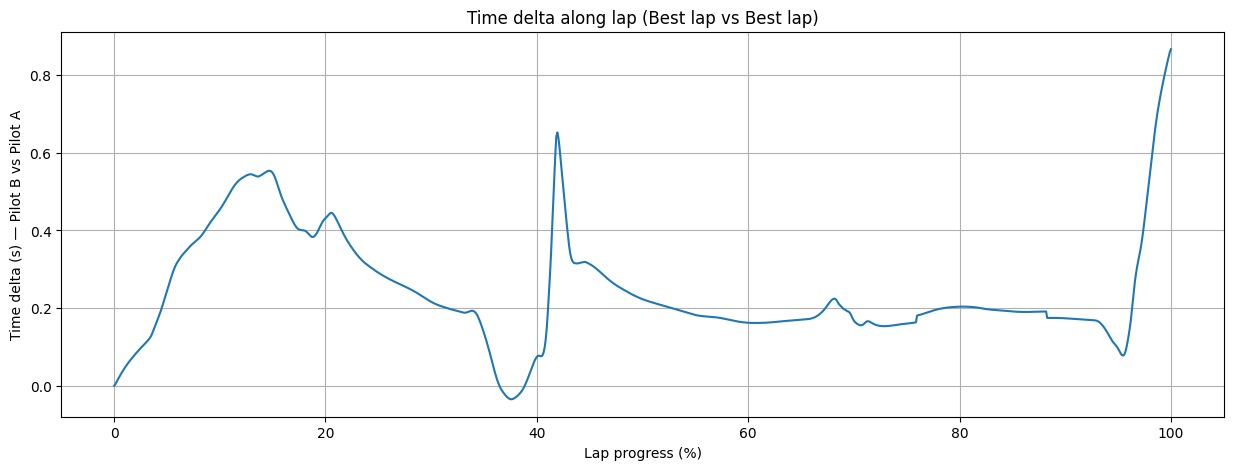

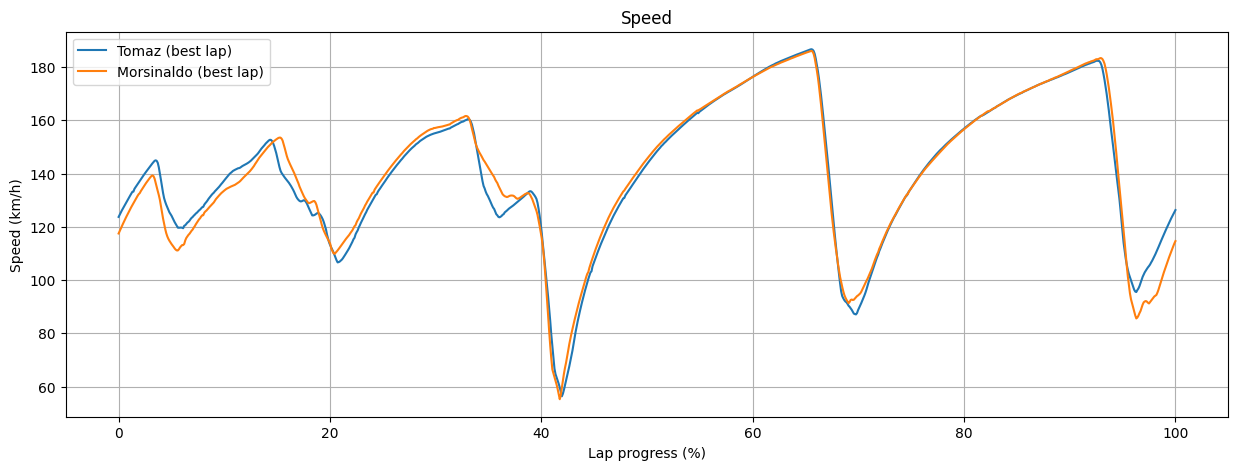

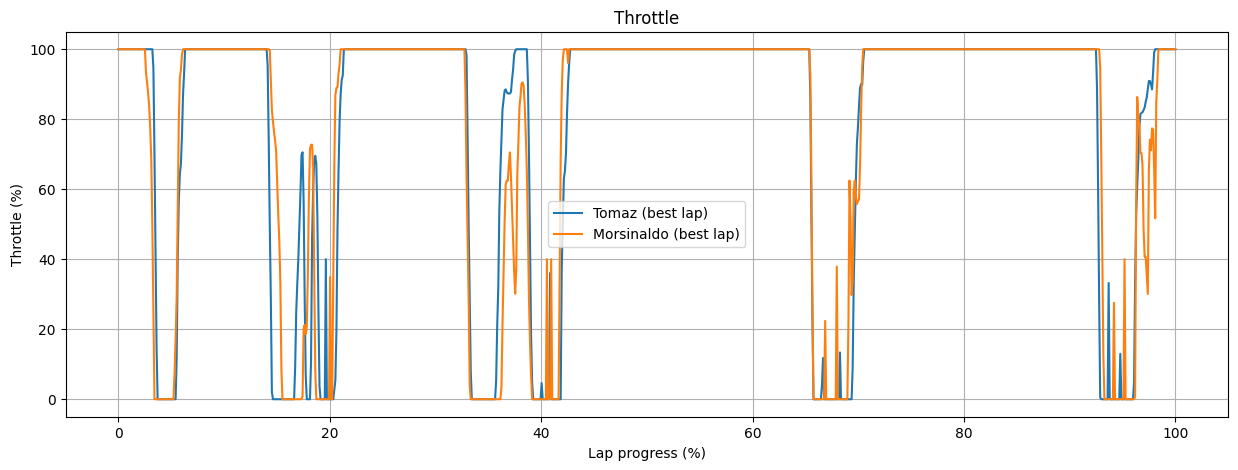

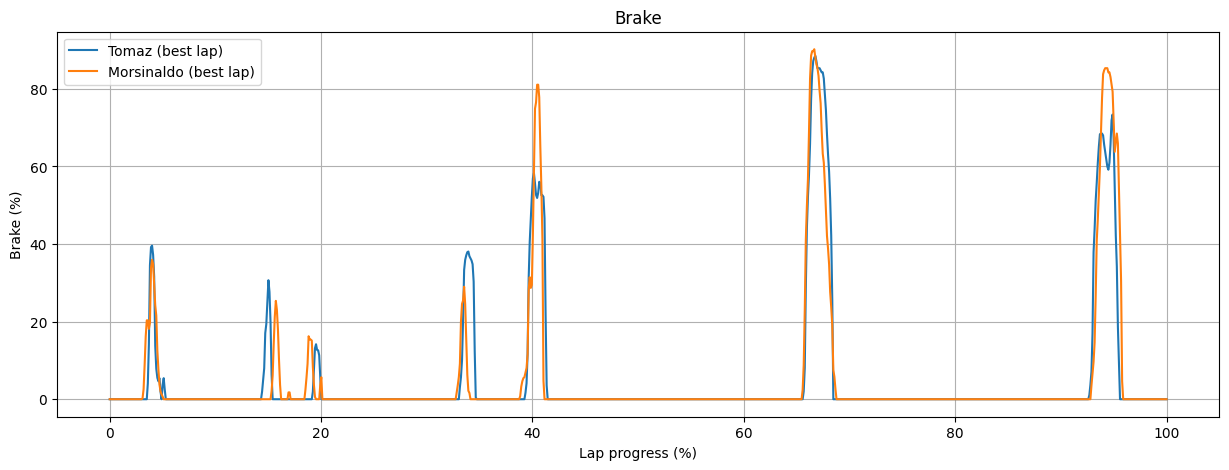

In [8]:
# --- Piloto A ---
lap_df_A = build_lap_validity_table(tomaz_df)
best_row_A = lap_df_A[lap_df_A["Valid"]].sort_values("LapTime_s").iloc[0]
best_lap_A = int(best_row_A["Lap"])

# --- Piloto B ---
lap_df_B = build_lap_validity_table(morsinaldo_df)
best_row_B = lap_df_B[lap_df_B["Valid"]].sort_values("LapTime_s").iloc[0]
best_lap_B = int(best_row_B["Lap"])

print(f"Piloto A - Best lap: {best_lap_A} ({format_laptime(best_row_A['LapTime_s'])})")
print(f"Piloto B - Best lap: {best_lap_B} ({format_laptime(best_row_B['LapTime_s'])})")

# Alinhamento por distância
grid = np.linspace(0.0, 1.0, BASE_GRID_LEN)

g_A = tomaz_df[tomaz_df["Lap"] == best_lap_A]
g_B = morsinaldo_df[morsinaldo_df["Lap"] == best_lap_B]

interp_A = align_lap_by_dist(g_A, grid)
interp_B = align_lap_by_dist(g_B, grid)


# Time-loss curve (target vs reference)
time_loss = interp_B["t_rel"] - interp_A["t_rel"]

plt.figure(figsize=(15, 5))
plt.plot(grid * 100.0, time_loss)
plt.xlabel("Lap progress (%)")
plt.ylabel("Time delta (s) — Pilot B vs Pilot A")
plt.title("Time delta along lap (Best lap vs Best lap)")
plt.grid(True)
plt.show()

def quick_plot(yA, yB, label, ylab):
    plt.figure(figsize=(15, 5))
    plt.plot(grid * 100.0, yA, label="Tomaz (best lap)")
    plt.plot(grid * 100.0, yB, label="Morsinaldo (best lap)")
    plt.xlabel("Lap progress (%)")
    plt.ylabel(ylab)
    plt.title(label)
    plt.legend()
    plt.grid(True)
    plt.show()

quick_plot(interp_A["speed"],    interp_B["speed"],    "Speed",    "Speed (km/h)")
quick_plot(interp_A["throttle"], interp_B["throttle"], "Throttle", "Throttle (%)")
quick_plot(interp_A["brake"],    interp_B["brake"],    "Brake",    "Brake (%)")




## 6. Sectorization and per-sector analysis

In the Charlotte track, we split the lap into **4 equal-length sectors** and compute per-sector **time, deltas, and simple signal differences**.


In [54]:
# --- CONSTANTES GEOGRÁFICAS (Charlotte Roval) ---
# Estes marcos dividem a pista em eventos reais (Curvas e Retas)
# Marcos exatos para 18 setores (19 pontos)
CUSTOM_EDGES = [
    0.000, 0.045, 0.080, 0.115, 0.145, 0.180, 0.220, 0.260, 0.310, 
    0.360, 0.430, 0.490, 0.580, 0.670, 0.740, 0.810, 0.880, 0.950, 1.000
]

SECTOR_NAMES = {
    1: "T1 (Heartlands)", 2: "T2", 3: "T3 (Infield)", 4: "T4", 
    5: "T5/T6 Transition", 6: "T7 (New Hairpin)", 7: "T8 (To Oval)", 
    8: "Oval Turn 1", 9: "Oval Turn 2", 10: "Backstretch", 
    11: "Bus Stop Entry", 12: "Bus Stop Apex", 13: "Bus Stop Exit", 
    14: "Oval Turn 3", 15: "Oval Turn 4", 
    16: "Final Chicane Entry", 17: "Final Chicane Exit", 18: "Frontstretch / Finish"
}

def sector_slices_by_edges(lap_dist_pct: np.ndarray, edges: list) -> list:
    """
    Divide a volta em fatias (slices) baseadas nos marcos geográficos CUSTOM_EDGES.
    """
    slices = []
    for i in range(len(edges) - 1):
        # Encontra os índices onde a distância da volta está entre as bordas do setor
        mask = (lap_dist_pct >= edges[i]) & (lap_dist_pct < edges[i+1])
        
        # Garante que o último ponto (1.0) seja incluído no último setor
        if i == len(edges) - 2:
            mask = (lap_dist_pct >= edges[i]) & (lap_dist_pct <= edges[i+1])
            
        indices = np.flatnonzero(mask)
        if indices.size > 0:
            slices.append(slice(indices[0], indices[-1] + 1))
        else:
            slices.append(slice(0, 0)) # Setor vazio (segurança)
    return slices

def sector_analysis(lap_A, lap_B, edges=CUSTOM_EDGES, label_A="A", label_B="B"):
    """
    Versão atualizada para comparar performance por Curvas Reais.
    """
    lap_dist = lap_A["LapDistPct"]
    slices = sector_slices_by_edges(lap_dist, edges)
    rows = []

    for i, sl in enumerate(slices, start=1):
        if sl.start == sl.stop: continue # Pula setores sem dados
        
        a, b = sl.start, sl.stop - 1
        time_A = float(lap_A["t_rel"][b] - lap_A["t_rel"][a])
        time_B = float(lap_B["t_rel"][b] - lap_B["t_rel"][a])

        rows.append({
            "Sector": i,
            "Turn": SECTOR_NAMES.get(i, f"S{i}"),
            "DeltaTime_s": time_B - time_A,
            "MeanSpeedDiff_kph": float(np.nanmean(lap_B["speed"][sl] - lap_A["speed"][sl])),
            "MeanBrakeDiff_pct": float(np.nanmean(lap_B["brake"][sl] - lap_A["brake"][sl]))
        })
    return pd.DataFrame(rows)

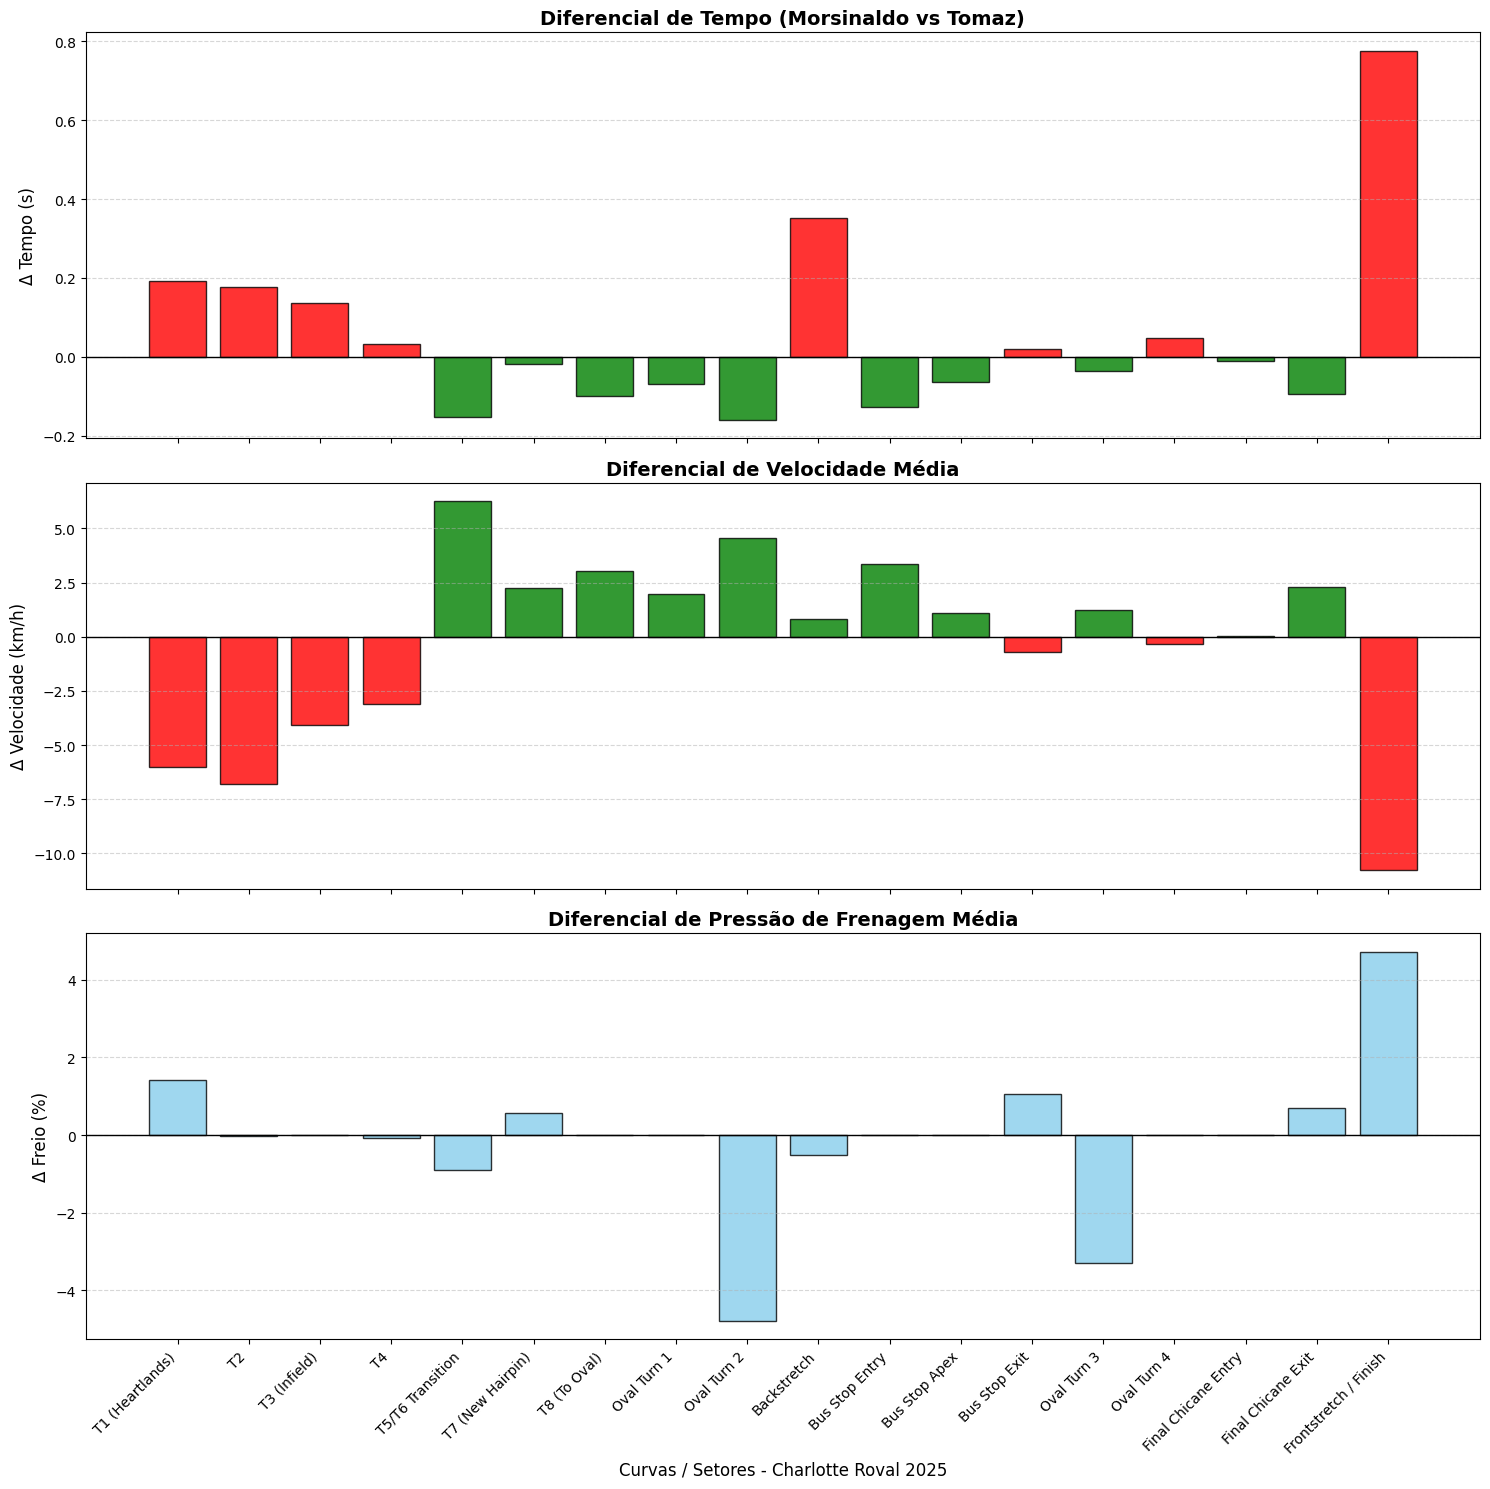

In [58]:
import matplotlib.pyplot as plt

# 1. Definimos os marcos geográficos em vez de um número fixo de setores
# Nota: N_SECTORS não é mais necessário aqui, pois usamos a lista de edges.
edges_roval = CUSTOM_EDGES 

# 2. Executamos a análise usando a nova função que aceita marcos customizados
sectors_AB = sector_analysis(
    interp_A,
    interp_B,
    edges=edges_roval,
    label_A="Tomaz",
    label_B="Morsinaldo",
)

# 3. Adicionamos os nomes das curvas para facilitar a leitura no seu relatório
sectors_AB["Turn"] = sectors_AB["Sector"].map(SECTOR_NAMES)

# 4. Reorganizamos as colunas para colocar o nome da curva em evidência
cols = ["Sector", "Turn", "DeltaTime_s", "MeanSpeedDiff_kph", "MeanBrakeDiff_pct"]
sectors_AB = sectors_AB[cols]

sectors_AB

# 1. Preparação dos dados (garantir que a coluna 'Turn' existe e está ordenada)
if "Turn" not in sectors_AB.columns:
    sectors_AB["Turn"] = sectors_AB["Sector"].map(SECTOR_NAMES)
df_plot = sectors_AB.sort_values("Sector")

# 2. Configuração da figura com 3 subplots verticais
fig, ax = plt.subplots(3, 1, figsize=(15, 15), sharex=True)

# --- Gráfico 1: Delta de Tempo ---
# Vermelho: Morsinaldo perde tempo (Delta > 0) | Verde: Morsinaldo ganha tempo (Delta < 0)
colors_time = ['red' if x > 0 else 'green' for x in df_plot["DeltaTime_s"]]
ax[0].bar(df_plot["Turn"], df_plot["DeltaTime_s"], color=colors_time, edgecolor='black', alpha=0.8)
ax[0].set_ylabel("Δ Tempo (s)", fontsize=12)
ax[0].set_title("Diferencial de Tempo (Morsinaldo vs Tomaz)", fontsize=14, fontweight='bold')
ax[0].axhline(0, color="black", linewidth=1)
ax[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- Gráfico 2: Delta de Velocidade Média ---
# Verde: Morsinaldo mais rápido (Diff > 0) | Vermelho: Morsinaldo mais lento (Diff < 0)
colors_speed = ['green' if x > 0 else 'red' for x in df_plot["MeanSpeedDiff_kph"]]
ax[1].bar(df_plot["Turn"], df_plot["MeanSpeedDiff_kph"], color=colors_speed, edgecolor='black', alpha=0.8)
ax[1].set_ylabel("Δ Velocidade (km/h)", fontsize=12)
ax[1].set_title("Diferencial de Velocidade Média", fontsize=14, fontweight='bold')
ax[1].axhline(0, color="black", linewidth=1)
ax[1].grid(axis='y', linestyle='--', alpha=0.5)

# --- Gráfico 3: Delta de Pressão de Freio ---
# Azul/Ciano para representar intensidade de freio
ax[2].bar(df_plot["Turn"], df_plot["MeanBrakeDiff_pct"], color='skyblue', edgecolor='black', alpha=0.8)
ax[2].set_ylabel("Δ Freio (%)", fontsize=12)
ax[2].set_title("Diferencial de Pressão de Frenagem Média", fontsize=14, fontweight='bold')
ax[2].axhline(0, color="black", linewidth=1)
ax[2].grid(axis='y', linestyle='--', alpha=0.5)

# Ajustes finais dos eixos
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.xlabel("Curvas / Setores - Charlotte Roval 2025", fontsize=12)

# Adiciona um pequeno padding para as legendas não cortarem
plt.tight_layout()
plt.show()


## New Heuristics



## Base Functions 

In [59]:
from scipy.signal import savgol_filter
from typing import List

# --- Funções de Cálculo de Heurísticas (DNA) ---

def compute_derivatives(sec: dict):
    t = sec["t_rel"]
    # dt robusto para dados com pequena variação de amostragem
    dt = np.mean(np.diff(t)) if len(t) > 1 else 0.01 

    brake = sec["brake"]
    throttle = sec["throttle"]

    # Cálculo da taxa de variação (Ramp Rates)
    brake_rate = np.gradient(brake, dt)
    throttle_rate = np.gradient(throttle, dt)

    # Suavização para remover ruído de sensor/input
    window = min(9, len(brake_rate))
    if window > 3 and window % 2 != 0:
        brake_rate = savgol_filter(brake_rate, window, 3)
        throttle_rate = savgol_filter(throttle_rate, window, 3)

    return brake_rate, throttle_rate

def braking_heuristics(sec: dict, brake_rate):
    d = {}
    brake_mask = sec["brake"] > 0.05  # Considera apenas quando há pressão real

    if np.any(brake_mask):
        d["BrakeRampRate"] = float(np.quantile(brake_rate[brake_mask], 0.95))
        d["BrakeConsistency"] = float(np.var(brake_rate[brake_mask]))
        d["BrakeEfficiency"] = float(abs(np.min(sec["long_accel"][brake_mask])) / 
                                     (np.max(sec["brake"][brake_mask]) + 1e-6))
    else:
        d["BrakeRampRate"], d["BrakeConsistency"], d["BrakeEfficiency"] = 0.0, 0.0, 0.0
    return d

def rotation_heuristics(sec: dict):
    d = {}
    speed = sec["speed"]
    yaw = sec["yaw_rate"]
    steer = sec["steering"]

    idx_vmin = np.argmin(speed)
    idx_mrp = np.argmax(np.abs(yaw)) # Maximum Rotation Point

    d["Vmin"] = float(speed[idx_vmin])
    d["Delta_MRP_Vmin"] = float(sec["t_rel"][idx_vmin] - sec["t_rel"][idx_mrp])

    # Eficiência: quanto o carro rotaciona por grau de volante
    avg_steer = np.mean(np.abs(steer))
    d["RotationEfficiency"] = float(np.mean(np.abs(yaw)) / (avg_steer + 1e-6)) if avg_steer > 1e-3 else 0.0
    return d

def acceleration_heuristics(sec: dict, throttle_rate):
    d = {}
    throttle_mask = sec["throttle"] > 0.05

    if np.any(throttle_mask):
        d["ThrottleAttackRate"] = float(np.quantile(throttle_rate[throttle_mask], 0.95))
        # Suavidade inversa à variância (evita divisão por zero)
        d["ThrottleSmoothness"] = float(1.0 / (np.var(throttle_rate[throttle_mask]) + 1e-6))
        d["ThrottleSteerConflict"] = float(np.mean(sec["throttle"] * np.abs(sec["steering"])))
    else:
        d["ThrottleAttackRate"], d["ThrottleSmoothness"], d["ThrottleSteerConflict"] = 0.0, 0.0, 0.0
    return d

def sector_heuristics(sec_raw: dict) -> dict:
    """Mapeia os canais brutos para o dicionário de heurísticas."""
    sec = {
        "t_rel": sec_raw["t_rel"],
        "speed": sec_raw["speed"],
        "brake": sec_raw["brake"],
        "throttle": sec_raw["throttle"],
        "steering": sec_raw["SteeringWheelAngle"],
        "yaw_rate": sec_raw["YawRate"],
        "long_accel": sec_raw.get("LongAccel", np.zeros_like(sec_raw["speed"])),
    }

    brake_rate, throttle_rate = compute_derivatives(sec)

    h = {}
    h.update(braking_heuristics(sec, brake_rate))
    h.update(rotation_heuristics(sec))
    h.update(acceleration_heuristics(sec, throttle_rate))
    return h

# --- Função Principal Atualizada para 2025 ---

def compute_sector_heuristics(interp: dict, edges=CUSTOM_EDGES) -> pd.DataFrame:
    """
    Calcula as heurísticas para cada curva definida nos CUSTOM_EDGES.
    """
    lap_dist = interp["LapDistPct"]
    rows = []

    # Cria as fatias baseadas nos marcos geográficos
    for i in range(len(edges) - 1):
        mask = (lap_dist >= edges[i]) & (lap_dist < edges[i+1])
        if i == len(edges) - 2: # Último setor inclui o ponto 1.0
            mask = (lap_dist >= edges[i]) & (lap_dist <= edges[i+1])
            
        indices = np.flatnonzero(mask)
        if indices.size == 0: continue
            
        sl = slice(indices[0], indices[-1] + 1)
        sec_raw = {k: v[sl] for k, v in interp.items()}

        # Calcula o DNA técnico do setor
        h = sector_heuristics(sec_raw)

        # Constrói a linha com ID e Nome da Curva
        sid = i + 1
        h_row = {
            "Sector": sid,
            "Turn": SECTOR_NAMES.get(sid, f"Sector {sid}")
        }
        h_row.update(h)
        rows.append(h_row)

    return pd.DataFrame(rows)

## Driver A and B - Heuristics

In [61]:
# --- Piloto A (Tomaz) ---
# Substituímos n_sectors pelos marcos geográficos CUSTOM_EDGES
heur_A = compute_sector_heuristics(
    interp=interp_A,
    edges=CUSTOM_EDGES
)
heur_A.insert(0, "Pilot", "A")

# --- Piloto B (Morsinaldo) ---
heur_B = compute_sector_heuristics(
    interp=interp_B,
    edges=CUSTOM_EDGES
)
heur_B.insert(0, "Pilot", "B")

# Exibição do resumo do Piloto B para conferência das curvas de 2025
display(heur_B)

,Pilot,Sector,Turn,BrakeRampRate,BrakeConsistency,BrakeEfficiency,Vmin,Delta_MRP_Vmin,RotationEfficiency,ThrottleAttackRate,ThrottleSmoothness,ThrottleSteerConflict
0,B,1,T1 (Heartlands),43.372370,1044.518806,0.183431,117.486104,-4.417531,0.924852,0.777401,0.000396,4.641573
1,B,2,T2,-4.843270,216.333832,0.256434,111.116645,-1.013355,0.789077,157.466413,0.000317,25.608216
2,B,3,T3 (Infield),0.000000,0.000000,0.000000,124.351267,-2.218010,0.470617,0.000000,1000000.000000,60.689780
3,B,4,T4,0.000000,0.000000,0.000000,137.195891,-0.378083,0.594830,3.588957,0.002619,31.162377
4,B,5,T5/T6 Transition,62.283130,2118.738786,0.205640,129.079960,1.620004,0.839096,96.848271,0.000140,5.472092
5,B,6,T7 (New Hairpin),32.220266,615.957224,0.285769,109.836902,0.118373,0.595209,157.380593,0.000138,43.630586
6,B,7,T8 (To Oval),0.000000,0.000000,0.000000,118.124808,0.000000,0.992377,0.000000,1000000.000000,4.989823
7,B,8,Oval Turn 1,0.000000,0.000000,0.000000,143.878251,-3.504791,0.714808,0.000000,1000000.000000,29.605765
8,B,9,Oval Turn 2,62.758731,2526.579162,0.208155,135.445562,0.288949,0.937225,5.780106,0.000155,3.144856
9,B,10,Backstretch,75.004743,3379.160492,0.145049,55.275488,-0.556822,0.411787,124.463791,0.000234,40.637117


# Driver Feedback Rules

Esta seção implementa um pipeline de *coaching* baseado em regras para comparar duas voltas (A como referência e B como piloto avaliado) **por setor**. O objetivo é transformar séries temporais brutas (speed, brake, throttle, steering, yaw, RPM e gear) em:

1. **Estados interpretáveis** ao longo da volta (BRAKING, CORNER, EXIT, STRAIGHT).
2. **Métricas agregadas** por (Setor, Estado), permitindo comparação entre A e B.
3. **Deltas (B − A)** por métrica, para localizar onde o piloto perde tempo.
4. **Regras de feedback** que geram dicas curtas e acionáveis, com contexto de *onde* e *que tipo de curva* é.

A ideia central é reduzir a complexidade do sinal contínuo para um conjunto pequeno de indicadores por fase de pilotagem, o que facilita feedback para pilotos iniciantes e permite evolução incremental das regras ao longo do tempo.

## Utilitários de índice (primeiro e último evento)

Antes de extrair eventos (por exemplo, início e fim de frenagem), usamos dois utilitários simples:

- `_first_idx(mask)`: retorna o primeiro índice onde uma condição booleana é verdadeira.
- `_last_idx(mask)`: retorna o último índice onde uma condição booleana é verdadeira.

Essas funções são úteis para detectar “janelas de evento” em sinais contínuos, como:
- intervalo em que o freio está acima de um threshold;
- intervalo em que o throttle está acima de um threshold após o ápice;
- overlap entre freio e acelerador.

Esse padrão evita lógica repetida e padroniza o comportamento quando o evento não existe (retorna `None`).

In [16]:
def _first_idx(mask: np.ndarray):
    idx = np.flatnonzero(mask)
    return int(idx[0]) if idx.size else None

def _last_idx(mask: np.ndarray):
    idx = np.flatnonzero(mask)
    return int(idx[-1]) if idx.size else None

## Rotulagem de estados (BRAKING, CORNER, EXIT, STRAIGHT)

Para gerar dicas por fase, primeiro precisamos “entender” o que o carro está fazendo ao longo do tempo. A função `label_state_df` recebe um DataFrame com sinais normalizados em percentual e devolve um vetor de estados:

- **BRAKING**: freio acima do threshold.
- **CORNER**: lateralidade alta (steering e opcionalmente yaw), independentemente do throttle.
- **EXIT**: throttle alto **e** lateralidade baixa (carro já está alinhado).
- **STRAIGHT**: restante.

A ordem de prioridade é importante:

1. **BRAKING tem prioridade máxima**, porque durante a frenagem o comportamento é dominado pela desaceleração e estabilidade.
2. **CORNER vem em seguida**, para capturar curvas “flat-out” (throttle alto com volante carregado).
3. **EXIT só ocorre quando o carro está alinhado**, ou seja, throttle alto com baixa lateralidade, representando retomada na saída.
4. O que sobra vira **STRAIGHT**.

Esse esquema evita confundir “aceleração em curva” com “saída da curva” e produz estados mais coerentes para coaching.

In [17]:
import numpy as np
import pandas as pd


def label_state_df(
    g: pd.DataFrame,
    brake_th: float = 15.0,
    throttle_th: float = 60.0,
    steer_th: float = 1.0,        # 👈 menor
    latacc_th: float = 0.6,       # g lateral
    window: int = 15              # suavização
):
    """
    Estados:
    BRAKING / CORNER / EXIT / STRAIGHT

    Filosofia:
    - CORNER = lateral sustentada (não pico de volante)
    - EXIT = transição curta pós-curva
    - STRAIGHT = WOT estável
    """

    brake = g["Brake_Pct"].to_numpy()
    throttle = g["Throttle_Pct"].to_numpy()
    speed = g["Speed_KPH"].to_numpy()
    steer = g["SteeringWheelAngle"].to_numpy()

    latacc = (
        g["LatAccel"].to_numpy()
        if "LatAccel" in g.columns
        else np.zeros(len(g))
    )

    n = len(g)
    state = np.array(["STRAIGHT"] * n, dtype=object)

    # =========================
    # 1) BRAKING
    # =========================
    braking = brake > brake_th
    state[braking] = "BRAKING"

    # =========================
    # 2) CORNER (lateral sustentada)
    # =========================
    steer_rms = pd.Series(steer).rolling(
        window, center=True, min_periods=5
    ).std().to_numpy()

    lateral = (
        (np.abs(latacc) > latacc_th) |
        (steer_rms > steer_th)
    )

    corner = lateral & (~braking)
    state[corner] = "CORNER"

    # =========================
    # 3) EXIT (curta transição)
    # =========================
    d_speed = np.gradient(speed)

    exit_mask = (
        (throttle > throttle_th) &
        (~braking) &
        (~corner) &
        (d_speed > 0.05)
    )

    state[exit_mask] = "EXIT"

    # =========================
    # 4) STRAIGHT (estável)
    # =========================
    straight = (
        (throttle > 90) &
        (~braking) &
        (~corner) &
        (steer_rms < steer_th * 0.6) &
        (np.abs(latacc) < latacc_th * 0.7)
    )

    return pd.Series(state, index=g.index, name="State")


## Agregação por (Setor, Estado)

Após rotular cada amostra com um estado, a função `summarize_by_sector_and_state` transforma a volta em uma tabela agregada. O procedimento é:

1. **Divide a volta em setores** usando `LapDistPct` em intervalos uniformes (ex.: 4 setores por quartis).
2. **Cria um DataFrame temporário (`gtmp`)** com as colunas exigidas por `label_state_df`, reaproveitando a mesma assinatura.
3. **Gera o vetor de estados** para cada amostra.
4. **Segmenta trechos contínuos** com o mesmo estado (runs).  
   - Isso evita misturar momentos diferentes da pilotagem dentro do mesmo estado.
   - `min_len` remove segmentos muito curtos, que tendem a ser ruído de limiar.
5. Para cada segmento válido, calcula métricas relevantes e monta linhas “por trecho”.
6. Por fim, agrega (groupby) por **(Sector, State)** para obter uma tabela compacta por volta.

O resultado é uma tabela que representa “como foi a pilotagem em cada setor e em cada fase”, pronta para comparação entre A e B.

In [ ]:
import numpy as np
import pandas as pd
from collections import Counter

######## NÃO UTILIZADA ########
def summarize_by_sector_and_state(interp: dict, edges=CUSTOM_EDGES, min_len=5):
    """
    Agrupa a telemetria por Curvas Reais e Estados de Condução.
    """
    # 1. Extração de dados
    lap = interp["LapDistPct"]
    speed = interp["speed"]
    brake = interp["brake"]
    throttle = interp["throttle"]
    steer = interp.get("SteeringWheelAngle", np.zeros_like(speed))
    yaw = interp.get("YawRate", np.zeros_like(speed))
    gear = interp.get("Gear", np.zeros_like(speed))
    latacc = interp.get("LatAccel", np.zeros_like(speed))

    # 2. Setorização por Marcos Geográficos (Curvas)
    sector = np.clip(np.digitize(lap, edges, right=True), 1, len(edges)-1)

    # 3. Classificação de Estados
    gtmp = pd.DataFrame({
        "Brake_Pct": brake, "Throttle_Pct": throttle,
        "Speed_KPH": speed, "LatAccel": latacc, "SteeringWheelAngle": steer
    })
    # Usa a sua função label_state_df definida anteriormente
    state = label_state_df(gtmp).to_numpy()

    def segment_runs(vals):
        runs = []
        n = len(vals); i = 0
        while i < n:
            j = i + 1
            while j < n and vals[j] == vals[i]: j += 1
            runs.append((i, j, vals[i]))
            i = j
        return runs

    def _mode_int(arr):
        arr = arr[~np.isnan(arr)]
        if len(arr) == 0: return np.nan
        c = Counter(arr.astype(int).tolist())
        return float(c.most_common(1)[0][0])

    # 4. Processamento de Heurísticas
    rows = []
    for a, b, lab in segment_runs(state):
        if (b - a) < min_len: continue

        sid = int(Counter(sector[a:b].tolist()).most_common(1)[0][0])
        
        row = {
            "Sector": sid, "State": lab, "Len": int(b - a),
            "SpeedMean": float(np.mean(speed[a:b])),
            "Vmin": float(np.min(speed[a:b])),
            "ThrottleMean": float(np.mean(throttle[a:b])),
            "BrakePeak": float(np.max(brake[a:b])),
            "SteerRMS": float(np.sqrt(np.mean((steer[a:b])**2))),
            "EntrySpeed": float(speed[a]) # Velocidade no início do estado
        }
        rows.append(row)

    seg_df = pd.DataFrame(rows)
    if seg_df.empty: return seg_df

    # 5. Agregação Final
    agg = seg_df.groupby(["Sector", "State"], as_index=False).mean()
    return agg

def generate_dna_comparison(df_a, df_b):
    """
    Cria a tabela comparativa de DNA de Pilotagem com nomes de curvas.
    """
    # Merge das tabelas dos dois pilotos
    m = pd.merge(df_a, df_b, on=["Sector", "State"], suffixes=("_A", "_B"))
    
    # Adiciona nomes das curvas
    m["Turn_Name"] = m["Sector"].map(SECTOR_NAMES)
    
    # Lista de heurísticas para comparar
    metrics = ["Vmin", "BrakePeak", "EntrySpeed", "SteerRMS"]
    
    for col in metrics:
        if f"{col}_A" in m.columns and f"{col}_B" in m.columns:
            m[f"Delta_{col}"] = m[f"{col}_B"] - m[f"{col}_A"]

    # Reorganiza colunas para o relatório
    cols = ["Sector", "Turn_Name", "State"] + [f"Delta_{c}" for c in metrics]
    return m[cols].sort_values(by=["Sector", "State"])

In [62]:
def compare_pilot_heuristics_per_turn(heur_A, heur_B):
    """
    Une as heurísticas dos dois pilotos em uma única tabela de 18 linhas,
    calculando os deltas técnicos para cada curva.
    """
    # 1. Merge das tabelas (A e B já calculadas por compute_sector_heuristics)
    # Cada tabela já possui 18 linhas (uma por curva do Roval 2025)
    m = pd.merge(heur_A, heur_B, on=["Sector", "Turn"], suffixes=("_A", "_B"))
    
    # 2. Identifica automaticamente as colunas de métricas para calcular Delta
    # Remove colunas de identificação
    excluded = ["Pilot_A", "Pilot_B", "Sector", "Turn"]
    metrics = [c.replace("_A", "") for c in m.columns if c.endswith("_A") and c not in excluded]
    
    for col in metrics:
        col_a = f"{col}_A"
        col_b = f"{col}_B"
        # Delta = Morsinaldo (B) - Tomaz (A)
        m[f"Δ_{col}"] = m[col_b] - m[col_a]
        
    return m.sort_values("Sector")

# --- EXECUÇÃO ---
# 1. Calcula as heurísticas completas para os 18 setores
hA = compute_sector_heuristics(interp_A, edges=CUSTOM_EDGES)
hB = compute_sector_heuristics(interp_B, edges=CUSTOM_EDGES)

# 2. Gera a comparação final (Sem a divisão por estados)
dna_turns = compare_pilot_heuristics_per_turn(hA, hB)

# 3. Exibição
display(dna_turns.head())

,Sector,Turn,BrakeRampRate_A,BrakeConsistency_A,BrakeEfficiency_A,Vmin_A,Delta_MRP_Vmin_A,RotationEfficiency_A,ThrottleAttackRate_A,ThrottleSmoothness_A,...,ThrottleSteerConflict_B,Δ_BrakeRampRate,Δ_BrakeConsistency,Δ_BrakeEfficiency,Δ_Vmin,Δ_Delta_MRP_Vmin,Δ_RotationEfficiency,Δ_ThrottleAttackRate,Δ_ThrottleSmoothness,Δ_ThrottleSteerConflict
0,1,T1 (Heartlands),98.483634,7479.955533,0.177751,123.706425,-4.124928,1.051568,4.080718,0.000243,...,4.641573,-55.111264,-6435.436727,0.005680,-6.220322,-0.292603,-0.126716,-3.303316,0.000153,-0.526932
1,2,T2,-2.639359,7.222492,0.429773,119.467207,0.647981,0.572993,131.649204,0.000437,...,25.608216,-2.203910,209.111341,-0.173338,-8.350563,-1.661335,0.216084,25.817210,-0.000120,-16.702747
2,3,T3 (Infield),0.000000,0.000000,0.000000,127.482971,-3.059312,0.413334,0.000000,1000000.000000,...,60.689780,0.000000,0.000000,0.000000,-3.131704,0.841302,0.057283,0.000000,0.000000,1.480995
3,4,T4,22.061211,0.000000,0.313577,142.231564,-0.367024,0.357964,6.683540,0.000176,...,31.162377,-22.061211,0.000000,-0.313577,-5.035673,-0.011059,0.236866,-3.094583,0.002443,-37.298553
4,5,T5/T6 Transition,68.019414,3036.631546,0.188381,127.747433,1.199341,0.446972,114.483676,0.000071,...,5.472092,-5.736285,-917.892761,0.017259,1.332527,0.420663,0.392124,-17.635405,0.000070,-10.577719


## Geração das tabelas agregadas (A e B)

Com `summarize_by_sector_and_state`, geramos uma tabela por volta:

- `A_seg`: volta de referência (lap A)
- `B_seg`: volta do piloto avaliado (lap B)

Cada tabela contém linhas por (Setor, Estado) e colunas com as métricas agregadas.  
Essas tabelas são a base do passo seguinte: comparar A vs B e calcular deltas.

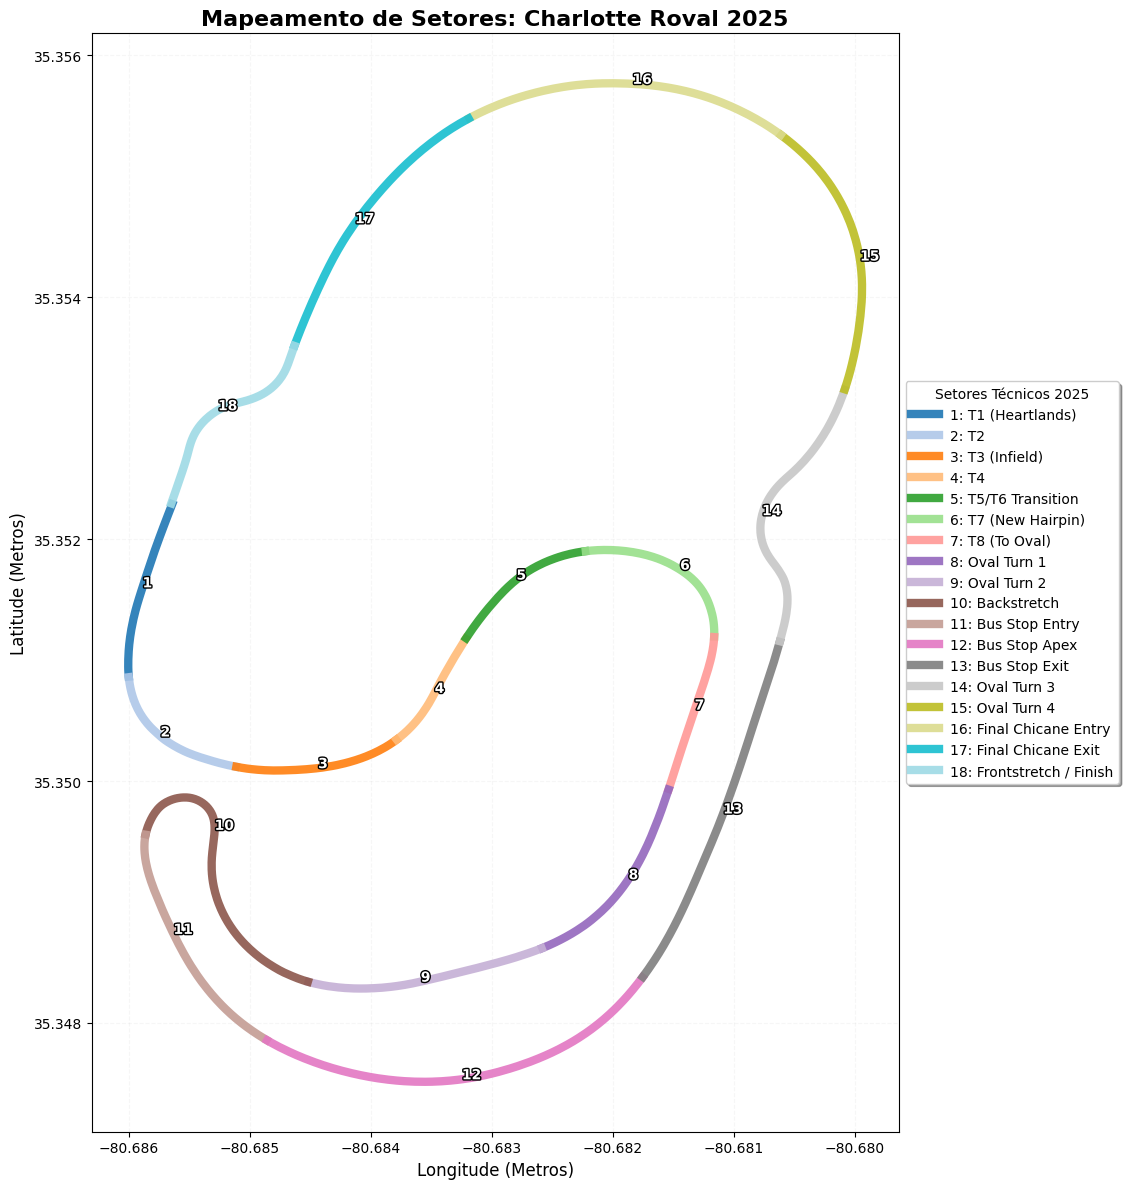

In [46]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects # <--- O IMPORT QUE FALTAVA
import numpy as np

def plot_geographic_sectors_2025(df, lap, edges=CUSTOM_EDGES, names=SECTOR_NAMES):
    # 1. Preparação e Normalização
    g = df[df["Lap"] == lap].copy().sort_values("SessionTime")
    
    # Garantir que a função de normalização que você já tem seja aplicada
    if g["LapDistPct"].max() > 1.5:
        g["LapDistPct"] /= 100.0
        
    # Atribuição de setores (1 a 18) conforme os marcos de 2025
    g["Sector"] = np.clip(np.digitize(g["LapDistPct"], edges, right=True), 1, len(edges)-1)
    
    # 2. Configuração do Mapa
    fig, ax = plt.subplots(figsize=(15, 12))
    cmap = plt.get_cmap('tab20', len(edges)-1)
    
    for sid in sorted(g["Sector"].unique()):
        sector_data = g[g["Sector"] == sid]
        if sector_data.empty: continue
        
        # Desenha o traçado do setor com cores distintas
        ax.plot(sector_data["Lon"], sector_data["Lat"], 
                color=cmap(sid-1), lw=6, alpha=0.9, 
                label=f"{sid}: {names.get(sid, 'Setor')}")
        
        # Rótulo centralizado no setor com contorno para legibilidade
        mid_idx = len(sector_data) // 2
        ax.text(sector_data["Lon"].iloc[mid_idx], sector_data["Lat"].iloc[mid_idx], 
                str(sid), fontsize=10, weight='bold', color='white',
                path_effects=[patheffects.withStroke(linewidth=2, foreground="black")]) # <--- Chamada corrigida

    # 3. Estética para Relatório Técnico
    ax.set_aspect('equal')
    ax.set_title(f"Mapeamento de Setores: Charlotte Roval 2025", fontsize=16, fontweight='bold')
    ax.set_xlabel("Longitude (Metros)", fontsize=12)
    ax.set_ylabel("Latitude (Metros)", fontsize=12)
    ax.grid(True, alpha=0.1, linestyle='--')
    
    # Legenda detalhada para conferência das 17 curvas + reta
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Setores Técnicos 2025", 
              fontsize=10, shadow=True, fancybox=True)
    
    plt.tight_layout()
    return fig, ax

# --- EXECUÇÃO ---
# Certifique-se que morsinaldo_df esteja carregado
fig, ax = plot_geographic_sectors_2025(morsinaldo_df, lap=8)
plt.show()

## Comparação A vs B por estado e setor (deltas B − A)

A função `compare_seg_tables` faz o merge das tabelas agregadas por:

- `Sector`
- `State`

e cria colunas `Δ_*` calculadas como **B − A** para cada métrica existente.

Por que usar deltas?

- As métricas absolutas variam por carro, setup e pista.
- O delta foca no que importa para coaching: **o que mudou em relação à referência**.
- Os deltas viram “features” de regras: exemplos
  - Δ_EntrySpeed negativo → piloto entra mais lento.
  - Δ_ThrottleOn_Speed negativo → piloto retoma com velocidade menor.
  - Δ_CoastFrac positivo → piloto está “tirando pé” mais tempo.

Além das métricas agregadas, também existe espaço para incluir colunas do pipeline 1 (como BrakeRampRate etc.), quando elas estiverem disponíveis em `A_seg` e `B_seg`.

In [63]:
def generate_master_comparison(heur_A, heur_B):
    """
    Versão otimizada da compare_seg_tables para análise por curva (sem States).
    Une os pilotos A e B e calcula deltas de todas as métricas.
    """
    # 1. Cruzamento apenas por Setor e Nome da Curva
    # (Removido o "State" para bater com sua nova filosofia de análise)
    m = pd.merge(heur_A, heur_B, on=["Sector", "Turn"], suffixes=("_A", "_B"))
    
    # 2. Identifica automaticamente as métricas (tudo que termina em _A)
    # Isso evita que você tenha que listar 50 nomes de colunas manualmente
    metrics = [c.replace("_A", "") for c in m.columns if c.endswith("_A") and c not in ["Pilot_A", "Turn_A"]]
    
    for col in metrics:
        col_a, col_b = f"{col}_A", f"{col}_B"
        if col_a in m.columns and col_b in m.columns:
            # Cálculo do Delta: B (Morsinaldo) - A (Tomaz)
            m[f"Δ_{col}"] = m[col_b] - m[col_a]
            
    return m.sort_values("Sector").reset_index(drop=True)

# --- COMO USAR AGORA ---
# 1. Gere as tabelas de 18 linhas para cada piloto
hA = compute_sector_heuristics(interp_A, edges=CUSTOM_EDGES)
hB = compute_sector_heuristics(interp_B, edges=CUSTOM_EDGES)

# 2. Crie a Master Table com os Deltas
seg_cmp = generate_master_comparison(hA, hB)

# 3. Verifique a estrutura (as 55 colunas estarão lá)
seg_cmp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Sector                   18 non-null     int64  
 1   Turn                     18 non-null     object 
 2   BrakeRampRate_A          18 non-null     float64
 3   BrakeConsistency_A       18 non-null     float64
 4   BrakeEfficiency_A        18 non-null     float64
 5   Vmin_A                   18 non-null     float64
 6   Delta_MRP_Vmin_A         18 non-null     float64
 7   RotationEfficiency_A     18 non-null     float64
 8   ThrottleAttackRate_A     18 non-null     float64
 9   ThrottleSmoothness_A     18 non-null     float64
 10  ThrottleSteerConflict_A  18 non-null     float64
 11  BrakeRampRate_B          18 non-null     float64
 12  BrakeConsistency_B       18 non-null     float64
 13  BrakeEfficiency_B        18 non-null     float64
 14  Vmin_B                   18 

## Extração de eventos por setor (apex e timings)

Além da visão por estado, usamos um segundo bloco para extrair eventos “pontuais” dentro de cada setor, como:

- **Vmin**: proxy do ápice (mínima velocidade do setor).
- **brake_on / brake_off**: início/fim da janela de freio acima do threshold.
- **throttle_on**: primeiro ponto de throttle acima do threshold após o ápice.

Com esses eventos calculamos métricas temporais relativas ao ápice (Vmin), como:

- **brake_lead_vs_vmin**: quanto antes do ápice o freio começa.
- **brake_release_vs_vmin**: quanto depois/antes do ápice o freio termina.
- **throttle_delay_vs_vmin**: quanto tempo após o ápice o throttle volta.

Esse conjunto é útil para regras mais “cinemáticas” (timing), complementando as métricas agregadas por estado.

In [64]:
def sector_events(sec, brake_th=0.05, throttle_th=0.05):
    t = sec["t_rel"]
    speed = sec["speed"]
    brake = sec["brake"]
    throttle = sec["throttle"]
    lap = sec["LapDistPct"]

    idx_vmin = int(np.argmin(speed))

    # brake_on/off: primeiro e último acima do threshold (dentro do setor)
    brake_mask = brake > brake_th
    idx_brake_on = _first_idx(brake_mask)
    idx_brake_off = _last_idx(brake_mask)

    # throttle_on: primeiro throttle após o vmin
    post = np.arange(len(t)) >= idx_vmin
    idx_throttle_on = _first_idx((throttle > throttle_th) & post)

    ev = {
        "t_vmin": float(t[idx_vmin]),
        "vmin": float(speed[idx_vmin]),
        "lap_vmin": float(lap[idx_vmin]) if lap is not None else None,

        "t_brake_on": float(t[idx_brake_on]) if idx_brake_on is not None else None,
        "t_brake_off": float(t[idx_brake_off]) if idx_brake_off is not None else None,

        "t_throttle_on": float(t[idx_throttle_on]) if idx_throttle_on is not None else None,
    }

    # relações ao apex (Vmin)
    ev["brake_lead_vs_vmin"] = (ev["t_vmin"] - ev["t_brake_on"]) if ev["t_brake_on"] is not None else None
    ev["throttle_delay_vs_vmin"] = (ev["t_throttle_on"] - ev["t_vmin"]) if ev["t_throttle_on"] is not None else None
    ev["brake_release_vs_vmin"] = (ev["t_brake_off"] - ev["t_vmin"]) if ev["t_brake_off"] is not None else None

    return ev

def compute_sector_events_table(interp, edges=CUSTOM_EDGES):
    """
    Versão atualizada: Extrai o TIMING de cada ação para as 18 curvas reais.
    """
    lap_dist = interp["LapDistPct"]
    rows = []
    
    # Criamos as fatias baseadas nos marcos geográficos das curvas
    for i in range(len(edges) - 1):
        mask = (lap_dist >= edges[i]) & (lap_dist < edges[i+1])
        if i == len(edges) - 2:
            mask = (lap_dist >= edges[i]) & (lap_dist <= edges[i+1])
            
        indices = np.flatnonzero(mask)
        if indices.size == 0: continue
            
        sl = slice(indices[0], indices[-1] + 1)
        sec = {k: v[sl] for k, v in interp.items()}
        sec["LapDistPct"] = interp["LapDistPct"][sl]
        
        # Chama a função que identifica o momento exato de cada evento
        ev = sector_events(sec)

        sid = i + 1
        row = {
            "Sector": sid, 
            "Turn": SECTOR_NAMES.get(sid, f"S{sid}"),
            **ev
        }
        rows.append(row)

    return pd.DataFrame(rows)

## Tabela de eventos por setor

`compute_sector_events_table` percorre todos os setores e aplica `sector_events` para cada slice da volta.

O resultado é uma tabela por volta (A e B) com:
- posição do ápice (lap_vmin),
- timings (t_brake_on/off, t_throttle_on),
- métricas relativas ao ápice.

Depois, `compare_sector_tables` faz o merge A vs B por setor e produz `Δ_*` das métricas principais.

Essa tabela é usada para detectar padrões de “timing”, como:
- frear cedo demais,
- soltar freio tarde demais,
- voltar ao throttle tarde demais.

In [65]:
def compare_sector_timing(evA, evB, sectors_AB):
    """
    Une os eventos de timing e correlaciona com o ganho/perda de tempo.
    """
    # 1. Merge dos eventos de timing (A e B)
    # Incluímos 'Turn' no merge para manter os nomes das curvas do Roval 2025
    m = evA.merge(evB, on=["Sector", "Turn"], suffixes=("_A", "_B"))
    
    # 2. Trazemos o DeltaTime_s (a performance final de cada setor)
    m = m.merge(sectors_AB[["Sector", "DeltaTime_s"]], on="Sector", how="left")

    # 3. Cálculo dos Deltas de Timing (B - A)
    # Valores negativos em brake_lead significam que B freou mais tarde
    # Valores positivos em throttle_delay significam que B demorou mais para acelerar
    timing_metrics = ["vmin", "brake_lead_vs_vmin", "throttle_delay_vs_vmin", "brake_release_vs_vmin"]
    
    for c in timing_metrics:
        if f"{c}_A" in m.columns and f"{c}_B" in m.columns:
            m[f"Δ_{c}"] = m[f"{c}_B"] - m[f"{c}_A"]

    return m.sort_values("Sector")

# --- EXECUÇÃO ATUALIZADA ---
# Chamando as funções com CUSTOM_EDGES em vez de N_SECTORS
evA = compute_sector_events_table(interp_A, edges=CUSTOM_EDGES)
evB = compute_sector_events_table(interp_B, edges=CUSTOM_EDGES)

# Gerando a tabela comparativa de timing
ev_cmp = compare_sector_timing(evA, evB, sectors_AB)

display(ev_cmp)

,Sector,Turn,t_vmin_A,vmin_A,lap_vmin_A,t_brake_on_A,t_brake_off_A,t_throttle_on_A,brake_lead_vs_vmin_A,throttle_delay_vs_vmin_A,...,t_brake_off_B,t_throttle_on_B,brake_lead_vs_vmin_B,throttle_delay_vs_vmin_B,brake_release_vs_vmin_B,DeltaTime_s,Δ_vmin,Δ_brake_lead_vs_vmin,Δ_throttle_delay_vs_vmin,Δ_brake_release_vs_vmin
0,1,T1 (Heartlands),0.000000,123.706425,0.000000,3.462917,4.225832,0.000000,-3.462917,0.0,...,4.417531,0.000000,-3.124130,0.0,4.417531,0.191699,-6.220322,0.338787,0.0,0.191699
1,2,T2,6.021651,119.467207,0.061061,4.327577,5.052967,6.021651,1.694074,0.0,...,5.088356,5.777568,1.250014,0.0,-0.689211,0.176500,-8.350563,-0.444060,0.0,0.279472
2,3,T3 (Infield),8.028008,127.482971,0.080080,NaN,NaN,8.028008,NaN,0.0,...,NaN,8.407036,NaN,0.0,NaN,0.137503,-3.131704,NaN,0.0,NaN
3,4,T4,11.364080,142.231564,0.115115,13.928762,13.928762,11.364080,-2.564683,0.0,...,NaN,11.884143,NaN,0.0,NaN,0.031170,-5.035673,NaN,0.0,NaN
4,5,T5/T6 Transition,17.245634,127.747433,0.179179,14.014869,14.722247,NaN,3.230765,NaN,...,16.763302,17.645919,2.394398,0.0,-0.882616,-0.152304,1.332527,-0.836367,NaN,1.640771
5,6,T7 (New Hairpin),20.230933,106.637928,0.207207,18.569092,19.307217,20.230933,1.661842,0.0,...,19.850664,20.319869,2.074692,0.0,-0.469205,-0.019667,3.198974,0.412851,0.0,0.454511
6,7,T8 (To Oval),21.787046,113.534409,0.220220,NaN,NaN,21.787046,NaN,0.0,...,NaN,22.162177,NaN,0.0,NaN,-0.098857,4.590399,NaN,0.0,NaN
7,8,Oval Turn 1,25.844544,141.634086,0.260260,NaN,NaN,25.844544,NaN,0.0,...,NaN,26.119388,NaN,0.0,NaN,-0.069904,2.244164,NaN,0.0,NaN
8,9,Oval Turn 2,34.560790,123.725751,0.359359,31.893556,33.219391,34.560790,2.667235,0.0,...,32.844538,NaN,2.765587,NaN,-1.760292,-0.159961,11.719810,0.098353,NaN,-0.418893
9,10,Backstretch,41.765629,56.374464,0.419419,37.876684,40.466783,41.765629,3.888945,0.0,...,40.139278,41.861094,4.442677,0.0,-1.721816,0.352506,-1.098977,0.553732,0.0,-0.422970


## Contexto textual da dica: posição no setor e tipo de curva (proxy)

Para que a mensagem de coaching seja mais compreensível, adicionamos um prefixo com:

1. **Setor** (S1..Sn).
2. **Posição no setor**: início, meio ou fim (derivado de LapDistPct relativo ao intervalo do setor).
3. **Tipo de curva**: reta/aberta, média ou fechada.

O tipo de curva é estimado por um proxy geométrico:
- mede picos locais de yaw e steer em uma janela “à frente” do evento,
- transforma o valor em percentil dentro de uma distribuição construída ao longo da volta,
- classifica em níveis (aberta/média/fechada).

A motivação é prática: pilotos iniciantes entendem melhor “onde” e “que tipo de curva” do que apenas uma métrica abstrata.

In [74]:
def sector_position_label(lap_pct: float, sector_id: int, edges=CUSTOM_EDGES) -> str:
    """Usa as bordas reais para definir início/meio/fim da curva."""
    if not np.isfinite(lap_pct) or sector_id > len(edges)-1:
        return "posição indefinida"
    
    s0 = edges[sector_id - 1]
    s1 = edges[sector_id]
    
    # Cálculo da posição relativa dentro da curva real
    # u = (lap_pct - s0) / (s1 - s0)
    u = (lap_pct - s0) / (s1 - s0 + 1e-12)
    
    if u < 0.33: return "entrada" # Início da curva/setor
    if u < 0.66: return "ápice"   # Meio da curva/setor
    return "saída"               # Fim da curva/setor

def peak_proxy_ahead(interp: dict, lap_pct: float, ahead_pct: float = 0.02, window_pct: float = 0.004):
    """
    Retorna o pico de curvatura e pico de steer em uma janela [lap, lap+ahead].
    - ahead_pct=0.02 => olha até +2% da volta (ótimo para pegar a curva depois da frenagem)
    """
    lap = interp.get("LapDistPct", None)
    if lap is None or not np.isfinite(lap_pct):
        return np.nan, np.nan

    lap = np.asarray(lap)

    # máscara lookahead (sem wrap-around por enquanto; suficiente pra dentro do setor)
   # Adicione o operador de módulo % 1.0 para lidar com a virada da volta
    m = (lap >= (lap_pct - window_pct) % 1.0) & (lap <= (lap_pct + ahead_pct) % 1.0)
    if not np.any(m):
        return np.nan, np.nan

    speed = np.asarray(interp.get("speed", np.nan*np.ones_like(lap)))

    # yaw proxy
    yaw_peak = np.nan
    if interp.get("YawRate", None) is not None:
        yaw = np.asarray(interp["YawRate"])
        v_ms = speed[m] / 3.6
        valid = (v_ms > 2.0) & np.isfinite(yaw[m]) & np.isfinite(v_ms)
        if np.any(valid):
            vals = np.abs(yaw[m][valid]) / (v_ms[valid] + 1e-6)
            yaw_peak = float(np.nanmax(vals))

    # steer proxy
    steer_peak = np.nan
    if interp.get("SteeringWheelAngle", None) is not None:
        steer = np.asarray(interp["SteeringWheelAngle"])
        vals = np.abs(steer[m])
        vals = vals[np.isfinite(vals)]
        if vals.size:
            steer_peak = float(np.nanmax(vals))

    return yaw_peak, steer_peak

def build_proxy_distributions(interp: dict):
    sample_pcts = np.linspace(0.01, 0.99, 250)
    yaw_vals, st_vals = [], []
    for p in sample_pcts:
        ypk, spk = peak_proxy_ahead(interp, p, ahead_pct=0.02, window_pct=0.003)
        if np.isfinite(ypk): yaw_vals.append(ypk)
        if np.isfinite(spk): st_vals.append(spk)
    return np.sort(np.asarray(yaw_vals)), np.sort(np.asarray(st_vals))

def percentile_rank(sorted_vals: np.ndarray, x: float) -> float:
    if sorted_vals.size == 0 or not np.isfinite(x):
        return np.nan
    return float(np.searchsorted(sorted_vals, x, side="right") / sorted_vals.size)

def label_from_percentile(p: float) -> str:
    if not np.isfinite(p):
        return "geometria indefinida"
    if p >= 0.80:
        return "curva fechada"
    if p >= 0.55:
        return "curva média"
    return "reta ou curva aberta"

def pick_event_lappct(row: pd.Series, state: str) -> float:
    """Escolhe o LapPct onde a dica realmente acontece (âncora do texto)."""
    if state == "EXIT":
        v = row.get("ThrottleOn_Lap_B", np.nan)
        if np.isfinite(v):
            return float(v)
    if state == "BRAKING":
        v = row.get("BrakePeak_Lap_B", np.nan)
        if np.isfinite(v):
            return float(v)
    return float(row.get("LapMid_B", np.nan))


def pick_geometry_lappct(row_dict: dict, state: str, rule_id: str = "") -> float:
    """
    Onde medir a geometria:
    - BRAKING: olhar adiante do pico de freio (pegar curva após a frenagem)
    - EXIT:
        * se a dica é de 'saída limitada' (linha/ápice), medir mais perto do miolo (LapMid)
        * se a dica é de gear/rpm, medir perto do throttle-on
    """
    if state == "BRAKING":
        p = row_dict.get("BrakePeak_Lap_B", np.nan)
        return float(p) if np.isfinite(p) else float(row_dict.get("LapMid_B", np.nan))

    if state == "EXIT":
        # para dicas de saída, a curva relevante é perto do throttle-on (saída da curva)
        p = row_dict.get("ThrottleOn_Lap_B", np.nan)
        if np.isfinite(p):
            # um pouco ANTES do throttle-on costuma pegar mais "raio" (ainda com volante)
            return float(p - 0.003)
        return float(row_dict.get("LapMid_B", np.nan))

    return float(row_dict.get("LapMid_B", np.nan))

def format_tip_prefix(interp_B: dict,
                      sector_id: int,
                      lap_event: float,
                      lap_geom: float,
                      dist_yaw: np.ndarray,
                      dist_steer: np.ndarray,
                      tip_state: str,
                      n_sectors: int = 4) -> str:

    pos = sector_position_label(lap_event, sector_id, n_sectors=n_sectors)

    # Para BRAKING/EXIT, o lookahead é essencial. Para outros, pode ser menor.
    ahead = 0.03 if tip_state == "BRAKING" else (0.02 if tip_state == "EXIT" else 0.01)

    ypk, spk = peak_proxy_ahead(interp_B, lap_geom, ahead_pct=ahead, window_pct=0.003)

    py = percentile_rank(dist_yaw, ypk)
    ps = percentile_rank(dist_steer, spk)

    # decide pelo sinal mais confiável (o que der percentil válido e maior)
    cand = [(py, "yaw"), (ps, "steer")]
    cand = [(p, src) for (p, src) in cand if np.isfinite(p)]
    if not cand:
        ctype = "geometria indefinida"
    else:
        p_best, _ = max(cand, key=lambda t: t[0])
        ctype = label_from_percentile(p_best)

    return f"Setor {sector_id} · {pos} · {ctype}: "


## Regras de coaching (`DRIVING_RULES`)

As regras são declaradas como uma lista de dicionários com:

- `id`: identificador único.
- `state`: estado ao qual a regra se aplica (BRAKING/CORNER/EXIT).
- `condition(A, B)`: lógica booleana que decide se a dica deve disparar.
- `message` ou `message_fn`: texto fixo ou texto dinâmico.
- `priority`: importância relativa para ordenar dicas.
- `group` (opcional): agrupamento para evitar múltiplas dicas redundantes sobre o mesmo fenômeno.

Exemplo de regra adicionada para piloto iniciante:
- **ENTRY_SPEED_TOO_LOW**: quando B entra significativamente mais lento que A (EntrySpeed).

Isso gera dicas com números concretos (km/h), que tendem a ser mais acionáveis para quem está começando.

### Sumário das regras atuais

Abaixo está um resumo das regras presentes no seu bloco `DRIVING_RULES`, organizadas por fase (state) e com seus gatilhos principais.

#### Entrada e frenagem (state = BRAKING)

- **ENTRY_SPEED_TOO_LOW** *(grupo: ENTRY_SPEED, prioridade 4)*  
  Dispara quando a velocidade de entrada do piloto (B) está pelo menos ~8 km/h abaixo da referência (A).  
  Objetivo: sugerir uma entrada mais carregada, com magnitude aproximada do delta em km/h.

- **ENTRY_OVER_SLOW** *(grupo: ENTRY_SPEED, prioridade 3)*  
  Dispara quando B usa pico de freio > 10% acima da referência **e ainda assim** chega no miolo mais lento (Vmin menor).  
  Objetivo: identificar “over-slow” (frear demais), com foco em reduzir pico e melhorar liberação do freio.

- **ENTRY_SPEED_TARGET** *(prioridade 2)*  
  Dispara quando B está mais lento que A na entrada (> ~3 km/h), **sem** estar freando mais forte (guardrail via BrakePeak).  
  Objetivo: dar uma recomendação conservadora de ajuste (+2 a +4 km/h) quando o problema é “timidez” e não “excesso de freio”.

- **F1_AGGRESSIVE_UNSTABLE_BRAKE** *(prioridade 3)*  
  Dispara quando, em relação à referência, B apresenta aumento relevante de *BrakeRampRate* e piora de *BrakeConsistency*.  
  Objetivo: indicar entrada de freio agressiva e pouco modulada (instabilidade na frenagem).

- **F2_CONSERVATIVE_INEFFICIENT_BRAKE** *(prioridade 2)*  
  Dispara quando B reduz *BrakeRampRate* (frenagem mais “mansa”) e piora *BrakeEfficiency*.  
  Objetivo: indicar frenagem progressiva demais e pouco eficiente.

#### Meio de curva e rotação (state = CORNER)

- **R3_ROTATION_INEFFICIENT** *(prioridade 2)*  
  Dispara quando a *RotationEfficiency* de B piora (mais volante sem retorno proporcional em rotação).  
  Objetivo: reduzir esterço “ineficiente” e correções no meio da curva.

- **R1_LATE_ROTATION** *(prioridade 2)*  
  Dispara quando B mantém Vmin um pouco maior, mas a rotação acontece tarde (Δ_MRP_Vmin maior).  
  Objetivo: alertar que a rotação está chegando atrasada em relação ao ápice, mesmo com boa Vmin.

#### Saída e tração (state = EXIT)

- **LATE_THROTTLE_LOW_SPEED** *(prioridade 3)*  
  Dispara quando B inicia aceleração cheia com velocidade significativamente menor do que A (ThrottleOn_Speed menor).  
  Objetivo: sugerir preservar velocidade no miolo e alinhar mais cedo para liberar throttle melhor.

- **LONG_GEAR_EXIT** *(prioridade 2)*  
  Dispara quando B está em marcha mais longa no throttle-on e com RPM menor do que a referência.  
  Objetivo: sugerir uma marcha a menos para motor mais cheio na retomada.

- **A2_AGGRESSIVE_THROTTLE_UNSMOOTH** *(prioridade 2)*  
  Dispara quando B aumenta *ThrottleAttackRate* e piora *ThrottleSmoothness*.  
  Objetivo: indicar aplicação de throttle agressiva e pouco progressiva.

- **A4_THROTTLE_STEER_CONFLICT** *(prioridade 3)*  
  Dispara quando B aumenta *ThrottleAttackRate* e aumenta *ThrottleSteerConflict* (throttle com volante carregado).  
  Objetivo: alertar risco de perda de tração por confiança excessiva na saída.

In [27]:
DRIVING_RULES = [
    {
        "id": "ENTRY_SPEED_TOO_LOW",
        "group": "ENTRY_SPEED",
        "state": "BRAKING",
        "condition": lambda A, B: (
            np.isfinite(B.get("EntrySpeed", np.nan)) and
            np.isfinite(A.get("EntrySpeed", np.nan)) and
            (A["EntrySpeed"] - B["EntrySpeed"]) / A["EntrySpeed"] > 0.02 # 2% de diferença
        ),
        "message": (
            "Velocidade de entrada conservadora: você entra na curva a "
            "{entry_b:.0f} km/h, enquanto a referência entra a {entry_a:.0f} km/h. "
            "Teste carregar a entrada cerca de {delta:.0f} km/h mais rápido, "
            "mantendo pressão de freio progressiva."
        ),
        "priority": 4
    },

    {
        "id": "ENTRY_OVER_SLOW",
        "group": "ENTRY_SPEED",   # 👈 mesmo grupo
        "state": "BRAKING",
        "condition": lambda A, B: (
            B["BrakePeak"] > A["BrakePeak"] * 1.10 and
            (B["Vmin"] - A["Vmin"]) / A["Vmin"] < -0.03 # Vmin piora >3%
        ),
        "message": (
            "Você aplica mais pico de freio, mas chega no miolo mais lento. "
            "Indício de over-slow na entrada. Teste reduzir o pico e soltar o freio "
            "de forma mais progressiva."
        ),
        "priority": 3
    },

    {
        "id": "LATE_THROTTLE_LOW_SPEED",
        "state": "EXIT",
        "condition": lambda A, B: (
            (B["t_ThrottleOn"] - A["t_ThrottleOn"]) / B["SectorTime"] > 0.08 # atraso >8%
        ),
        "message": (
            "Você inicia a aceleração cheia com velocidade menor. "
            "Indício de ápice ou linha que limita a saída. "
            "Foques em preservar velocidade no miolo e alinhar o carro mais cedo."
        ),
        "priority": 3
    },

    {
        "id": "LONG_GEAR_EXIT",
        "state": "EXIT",
        "condition": lambda A, B: (
            B["GearAtThrottleOn"] > A["GearAtThrottleOn"] and #marcga errada 
            (B["AccelEfficiency"] < A["AccelEfficiency"] * 0.95) # eficiência piora >5%
        ),
        "message": (
            "No throttle-on você está em marcha mais longa e com RPM menor. "
            "Teste uma marcha a menos para manter o motor mais cheio na retomada."
        ),
        "priority": 2
    },

    # F1 — Frenagem agressiva e instável
    {
        "id": "F1_AGGRESSIVE_UNSTABLE_BRAKE",
        "state": "BRAKING",
        "condition": lambda A,B: (
            # Ataque mais agressivo (+25%) e consistência piorada (+30%)
            (B["BrakeRampRate"] / A["BrakeRampRate"]) > 1.25 and
            (B["BrakeConsistency"] / A["BrakeConsistency"]) > 1.30
        ),
        "message": "Entrada de freio mais agressiva e menos estável que a referência. "
                    "Tente suavizar o ataque inicial e modular melhor a pressão.",
        "priority": 3
    },

    # F2 — Frenagem conservadora e ineficiente
    {
        "id": "F2_CONSERVATIVE_INEFFICIENT_BRAKE",
        "state": "BRAKING",
        "condition": lambda A,B: (
            (B["BrakeRampRate"] / A["BrakeRampRate"] < 0.80) and # ataque mais suave (-20%)
            (B["BrakeEfficiency"] / A["BrakeEfficiency"] < 0.95) # eficiência piora >5%
        ),
        "message": "Aplicação de freio excessivamente progressiva, com baixa eficiência de desaceleração.",
        "priority": 2
    },

    # R3 — Rotação ineficiente por excesso de volante
    {
        "id": "R3_ROTATION_INEFFICIENT",
        "state": "CORNER",
        "condition": lambda A,B: (
            (B.get("RotationEfficiency", np.nan) - A.get("RotationEfficiency", np.nan) < -0.05) and
            (B["Vmin"] < A["Vmin"] * 0.97) # Vmin piora >3%
        ),
        "message": "Uso excessivo de volante sem retorno proporcional em rotação do carro.",
        "priority": 2
    },

    # R1 — Vmin ok mas rotação tardia (MRP depois do vmin)
    {
        "id": "R1_LATE_ROTATION",
        "state": "CORNER",
        "condition": lambda A,B: (
            (B.get("Vmin", np.nan) - A.get("Vmin", np.nan) > 0.5) and
            (B.get("Delta_MRP_Vmin", np.nan) - A.get("Delta_MRP_Vmin", np.nan) > 0.10)
        ),
        "message": "Boa velocidade mínima, mas a rotação do carro acontece tarde em relação ao ápice.",
        "priority": 2
    },

    # A2 — Aceleração agressiva e pouco suave
    {
        "id": "A2_AGGRESSIVE_THROTTLE_UNSMOOTH",
        "state": "EXIT",
        "condition": lambda A,B: (
            (B.get("ThrottleAttackRate", np.nan) - A.get("ThrottleAttackRate", np.nan) > 15) and
            (B.get("ThrottleSmoothness", np.nan) - A.get("ThrottleSmoothness", np.nan) < 0) and
            (B["ThrottleSteerConflict"] > A["ThrottleSteerConflict"] * 1.2) # conflito lateral piora >20%
        ),
        "message": "Aplicação do acelerador muito agressiva e pouco progressiva na saída da curva.",
        "priority": 2
    },

    # A4 — Perda de tração por excesso de confiança (throttle com volante)
    {
        "id": "A4_THROTTLE_STEER_CONFLICT",
        "state": "EXIT",
        "condition": lambda A,B: (
            (B.get("ThrottleAttackRate", np.nan) - A.get("ThrottleAttackRate", np.nan) > 10) and
            (B.get("ThrottleSteerConflict", np.nan) - A.get("ThrottleSteerConflict", np.nan) > 0.05) 
        ),
        "message": "O acelerador é aplicado cedo demais com o volante ainda carregado, causando perda de eficiência na saída.",
        "priority": 3
    },
    {
        "id": "ENTRY_SPEED_TARGET",
        "state": "BRAKING",
        "condition": lambda A, B: (
            np.isfinite(A.get("EntrySpeed", np.nan)) and
            np.isfinite(B.get("EntrySpeed", np.nan)) and
            (B["EntrySpeed"] < A["EntrySpeed"] - 3.0) and
            # guardrails: evita duplicar "over-slow" e evita recomendar "carregar" quando você está freando mais forte
            (B.get("BrakePeak", np.nan) <= A.get("BrakePeak", np.nan) * 1.05)
        ),
        "message_fn": lambda A, B: (
            f"Velocidade de entrada: a referência entra a ~{A['EntrySpeed']:.1f} km/h, "
            f"e você entra a ~{B['EntrySpeed']:.1f} km/h (−{(A['EntrySpeed']-B['EntrySpeed']):.1f} km/h). "
            "Teste carregar +2 a +4 km/h na aproximação, mantendo o freio estável e sem aumentar o pico."
        ),
        "priority": 2
    },
]

## Geração das dicas por setor

`generate_sector_tips` recebe as linhas do `seg_cmp` de um setor e:

1. Separa os dicionários **A** e **B** retirando sufixos `_A` e `_B`.
2. Define `lap_event` (âncora do texto) usando:
   - BrakePeak_Lap para BRAKING,
   - ThrottleOn_Lap para EXIT,
   - LapMid em outros casos.
3. Percorre `DRIVING_RULES` filtrando por `state`.
4. Aplica `condition(A, B)` e, se verdadeiro:
   - constrói `msg` (via `message_fn` ou `message`),
   - tenta interpolar placeholders (ex.: entry_a, entry_b, delta),
   - registra a dica com prioridade, grupo e contexto.

O retorno é uma lista ordenada por prioridade, pronta para impressão no relatório final.

In [67]:
import numpy as np

DRIVING_RULES = [
    # --- GRUPO: ENTRADA E FRENAGEM ---
    {
        "id": "ENTRY_OVER_SLOW",
        "category": "Frenagem",
        "condition": lambda A, B: (
            B.get("BrakePeak", 0) > A.get("BrakePeak", 0) * 1.10 and
            (B.get("Vmin", 1) - A.get("Vmin", 1)) / A.get("Vmin", 1) < -0.03
        ),
        "message": (
            "Over-slow na entrada: você aplica mais pressão de freio (+10%), mas chega no ápice mais lento. "
            "Teste reduzir o pico inicial para manter mais velocidade de contorno."
        ),
        "priority": 1
    },
    
    {
        "id": "F1_AGGRESSIVE_UNSTABLE_BRAKE",
        "category": "Frenagem",
        "condition": lambda A, B: (
            (B.get("BrakeRampRate", 1) / (A.get("BrakeRampRate", 1) + 1e-6)) > 1.25 and
            (B.get("BrakeConsistency", 1) / (A.get("BrakeConsistency", 1) + 1e-6)) > 1.30
        ),
        "message": "Ataque ao freio muito agressivo e instável. Tente suavizar o início da frenagem para não desestabilizar a plataforma do carro.",
        "priority": 2
    },

    # --- GRUPO: ROTAÇÃO E MEIO DE CURVA ---
    {
        "id": "R3_ROTATION_INEFFICIENT",
        "category": "Rotação",
        "condition": lambda A, B: (
            (B.get("RotationEfficiency", 0) - A.get("RotationEfficiency", 0) < -0.05) and
            (B.get("Vmin", 0) < A.get("Vmin", 0) * 0.97)
        ),
        "message": "Subesterço detectado: você usa muito volante, mas o carro não rotaciona proporcionalmente. Tente virar menos ou frear antes.",
        "priority": 1
    },

    # --- GRUPO: SAÍDA E TRAÇÃO ---
    {
        "id": "LATE_THROTTLE_LOW_SPEED",
        "category": "Saída",
        "condition": lambda A, B: (
            # Verifica se o throttle-on ocorreu mais de 8% depois na volta em relação ao tempo do setor
            (B.get("t_throttle_on", 0) - A.get("t_throttle_on", 0)) > 0.100 # Atraso absoluto > 100ms
        ),
        "message": (
            "Aceleração tardia: você demora para retomar o acelerador cheio. "
            "Foque em posicionar o carro para 'abrir' o volante mais cedo na saída."
        ),
        "priority": 2
    },

    {
        "id": "A4_THROTTLE_STEER_CONFLICT",
        "category": "Tração",
        "condition": lambda A, B: (
            B.get("ThrottleSteerConflict", 0) > A.get("ThrottleSteerConflict", 0) * 1.20
        ),
        "message": "Conflito Acelerador x Volante: você está exigindo tração com o carro ainda muito virado, o que causa perda de tempo por falta de grip.",
        "priority": 2
    }
]

## Relatório final por setor (com prefixo de contexto)

`report_by_sector` é a função de apresentação:

- percorre setores em ordem,
- imprime o Δt do setor (B vs A),
- gera dicas do setor (até `max_tips`),
- calcula o prefixo contextual (posição e tipo de curva),
- imprime as mensagens finalizadas.

A separação entre:
- cálculo (tabelas e deltas),
- regras (DRIVING_RULES),
- apresentação (report_by_sector)

torna o pipeline mais fácil de manter: você pode incluir novas métricas e novas regras sem reestruturar todo o fluxo.

In [75]:
def generate_coaching_report(master_df, rules=DRIVING_RULES):
    report = []
    
    for _, row in master_df.iterrows():
        # Dicionários de A e B para a lambda
        # Nota: Extraímos os valores das colunas _A e _B
        data_A = {c.replace("_A", ""): row[c] for c in row.index if c.endswith("_A")}
        data_B = {c.replace("_B", ""): row[c] for c in row.index if c.endswith("_B")}
        
        curva_tips = []
        for rule in rules:
            if rule["condition"](data_A, data_B):
                curva_tips.append(f"[{rule['category']}] {rule['message']}")
        
        if curva_tips:
            report.append({
                "Curva": row["Turn"],
                "Dicas": curva_tips
            })
            
    return pd.DataFrame(report)

# Execução:
dicas_piloto = generate_coaching_report(seg_cmp)
display(dicas_piloto)

,Curva,Dicas
0,T1 (Heartlands),[[Rotação] Subesterço detectado: você usa muit...
1,T2,[[Frenagem] Ataque ao freio muito agressivo e ...
2,Bus Stop Entry,[[Tração] Conflito Acelerador x Volante: você ...
3,Bus Stop Exit,[[Rotação] Subesterço detectado: você usa muit...
4,Oval Turn 3,[[Tração] Conflito Acelerador x Volante: você ...
5,Frontstretch / Finish,[[Rotação] Subesterço detectado: você usa muit...


In [76]:
def sector_position_label(lap_pct: float, sector_id: int, edges=CUSTOM_EDGES) -> str:
    """Converte LapDistPct em 'entrada/ápice/saída' usando as bordas reais."""
    if not np.isfinite(lap_pct) or sector_id > len(edges)-1:
        return "posição indefinida"
    
    # Bordas reais da curva
    s0 = edges[sector_id - 1]
    s1 = edges[sector_id]
    
    # Progresso relativo (0 a 1) dentro da curva
    u = (lap_pct - s0) / (s1 - s0 + 1e-12)
    
    if u < 0.33: return "entrada"
    if u < 0.66: return "ápice"
    return "saída"

def format_tip_prefix(interp_B, sector_id, lap_event, lap_geom, dist_yaw, dist_steer, tip_state, edges=CUSTOM_EDGES):
    """Gera o prefixo descritivo (Ex: Curva 6 · ápice · curva fechada)."""
    # Agora passamos os edges para a função de posição
    pos = sector_position_label(lap_event, sector_id, edges=edges)
    
    ahead = 0.03 if tip_state in ["Frenagem", "BRAKING"] else 0.01
    ypk, spk = peak_proxy_ahead(interp_B, lap_geom, ahead_pct=ahead, window_pct=0.003)
    
    py = percentile_rank(dist_yaw, ypk)
    ps = percentile_rank(dist_steer, spk)
    
    cand = [p for p in [py, ps] if np.isfinite(p)]
    ctype = label_from_percentile(max(cand) if cand else np.nan)
    
    return f"Curva {sector_id} · {pos} · {ctype}: "

def generate_sector_tips(df_sector_cmp, max_tips=5):
    """Analisa as DRIVING_RULES sobre a linha da curva (Master Table)."""
    tips = []
    for _, row in df_sector_cmp.iterrows():
        # Cria dicionários limpos removendo os sufixos _A e _B
        A = {k.replace("_A", ""): row[k] for k in row.index if k.endswith("_A")}
        B = {k.replace("_B", ""): row[k] for k in row.index if k.endswith("_B")}
        
        # Injeta colunas extras se necessário para as lambdas
        B["SectorTime"] = row.get("DeltaTime_s", 0) # Simplificação para as regras

        for rule in DRIVING_RULES:
            if rule["condition"](A, B):
                # Define a categoria para o prefixo
                cat = rule.get("category", rule.get("state", "Geral"))
                
                # Busca o LapPct onde o evento ocorre (ex: pico de freio)
                lap_ev = pick_event_lappct(row, cat)
                
                tips.append({
                    "rule_id": rule["id"],
                    "message": rule["message"] if "message" in rule else rule["message_fn"](A, B),
                    "priority": rule.get("priority", 3),
                    "LapPct": lap_ev,
                    "category": cat,
                    "row": row.to_dict()
                })
    
    return sorted(tips, key=lambda x: x["priority"])[:max_tips]

In [78]:
def report_by_sector(seg_cmp: pd.DataFrame, sector_dt: pd.DataFrame, threshold=0.050, max_tips=3):
    """
    Gera o relatório focado em PERDAS técnicas, filtrando ruídos e 
    tratando as inconsistências geográficas da linha de chegada.
    """
    dist_yaw, dist_steer = build_proxy_distributions(interp_B)

    # 1. Filtramos apenas setores com perda de tempo significativa
    # Isso limpa o relatório de ganhos (deltas negativos) e foca no problema
    critical_sectors = sector_dt[sector_dt["DeltaTime_s"] > threshold].sort_values("DeltaTime_s", ascending=False)
    
    print(f"--- ANÁLISE DE PERDAS CRÍTICAS (>{threshold}s) ---")

    for _, row_dt in critical_sectors.iterrows():
        sid = int(row_dt["Sector"])
        dt = float(row_dt["DeltaTime_s"])
        turn_name = SECTOR_NAMES.get(sid, f"Setor {sid}")
        
        print(f"\n⚠️ Curva {sid}: {turn_name} | Δt = {dt:+.3f}s")

        df_sector = seg_cmp[seg_cmp["Sector"] == sid].copy()
        tips = generate_sector_tips(df_sector, max_tips=max_tips)

        if not tips:
            print("   ℹ️ Perda sem desvio técnico claro (provável linha, vácuo ou erro de marcha).")
        else:
            for i, t in enumerate(tips, 1):
                lap_event = t.get("LapPct", np.nan)
                row_dict = t.get("row", {})
                state = t.get("category", t.get("state", ""))

                lap_geom = pick_geometry_lappct(row_dict, state)

                # Gerar prefixo com tratamento de erros geográficos
                prefix = format_tip_prefix(
                    interp_B, sid,
                    lap_event=lap_event, lap_geom=lap_geom,
                    dist_yaw=dist_yaw, dist_steer=dist_steer,
                    tip_state=state, edges=CUSTOM_EDGES
                )
                
                # LIMPEZA: Remove o texto de "indefinida" se o código não encontrar a geometria
                # Útil para o Setor 18 (Reta) onde a física de curva não se aplica
                clean_prefix = prefix.replace("posição indefinida · ", "").replace("geometria indefinida: ", "")
                
                print(f"   {i}) {clean_prefix}{t['message']}")

# --- EXECUÇÃO ---
# Agora você foca apenas no que importa para a evolução do piloto
report_by_sector(seg_cmp, sectors_AB, threshold=0.050)

--- ANÁLISE DE PERDAS CRÍTICAS (>0.05s) ---

⚠️ Curva 18: Frontstretch / Finish | Δt = +0.776s
   1) Curva 18 · Subesterço detectado: você usa muito volante, mas o carro não rotaciona proporcionalmente. Tente virar menos ou frear antes.

⚠️ Curva 10: Backstretch | Δt = +0.353s
   ℹ️ Perda sem desvio técnico claro (provável linha, vácuo ou erro de marcha).

⚠️ Curva 1: T1 (Heartlands) | Δt = +0.192s
   1) Curva 1 · Subesterço detectado: você usa muito volante, mas o carro não rotaciona proporcionalmente. Tente virar menos ou frear antes.

⚠️ Curva 2: T2 | Δt = +0.177s
   1) Curva 2 · Ataque ao freio muito agressivo e instável. Tente suavizar o início da frenagem para não desestabilizar a plataforma do carro.

⚠️ Curva 3: T3 (Infield) | Δt = +0.138s
   ℹ️ Perda sem desvio técnico claro (provável linha, vácuo ou erro de marcha).


# Plots da rotulagem e dos setores

Esta seção existe para validação visual. Antes de confiar nas regras, é essencial conferir se:

1. Os setores estão corretamente delimitados no traçado.
2. Os estados (BRAKING/CORNER/EXIT/STRAIGHT) fazem sentido no mapa.
3. Os thresholds escolhidos (freio, throttle e steer) não estão gerando rotulagem errada.

Os mapas são úteis porque erros de segmentação (por exemplo, “CORNER” aparecendo em reta) geram feedback incorreto, mesmo que o código esteja tecnicamente funcionando.# Plots da rotulagem e dos setores

## Setores por LapDistPct

`assign_sector_by_lapdistpct` divide a volta em setores uniformes usando `LapDistPct` no intervalo [0, 1].  
A estratégia é simples e reprodutível:

- S1: [0.00, 0.25]
- S2: [0.25, 0.50]
- S3: [0.50, 0.75]
- S4: [0.75, 1.00]

Essa abordagem é suficiente para o primeiro protótipo e permite comparar voltas sem depender de “track map” externo.

In [80]:
def assign_sector_by_lapdistpct(lapdistpct: pd.Series, edges=CUSTOM_EDGES) -> pd.Series:
    """
    Atribui o setor correto (1-18) baseando-se nos marcos geográficos
    reais do Charlotte Roval 2025.
    """
    # np.digitize classifica os valores nos intervalos definidos pelos edges
    s = np.digitize(lapdistpct.to_numpy(), edges, right=True)
    
    # Garante que os valores fiquem entre 1 e o número total de setores (len(edges) - 1)
    n_total_sectors = len(edges) - 1
    s = np.clip(s, 1, n_total_sectors)
    
    return pd.Series(s, index=lapdistpct.index, name="Sector")

import folium
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_lap_map_by_sector(
    df: pd.DataFrame,
    lap: int,
    edges=CUSTOM_EDGES,
    tiles="OpenStreetMap",
    sample_step: int = 1
):
    # 1. Preparação dos dados
    g = df[df["Lap"] == lap].copy().sort_values("SessionTime")
    g = normalize_lapdistpct(g)
    g = g.dropna(subset=["Lat", "Lon", "LapDistPct"])

    if sample_step > 1:
        g = g.iloc[::sample_step].copy()

    # 2. Atribui setor baseado nos marcos reais
    g["Sector"] = assign_sector_by_lapdistpct(g["LapDistPct"], edges=edges)
    n_total_sectors = len(edges) - 1

    # 3. Configuração do Mapa
    lat0, lon0 = float(g["Lat"].iloc[0]), float(g["Lon"].iloc[0])
    m = folium.Map(location=[lat0, lon0], zoom_start=16, tiles=tiles)

    # 4. Geração dinâmica de 18 cores (usando o mapa de cores 'nipy_spectral' ou 'jet')
    cmap = plt.get_cmap('nipy_spectral', n_total_sectors)
    sector_colors = [mcolors.to_hex(cmap(i)) for i in range(n_total_sectors)]

    # 5. Desenha uma polyline por curva (setor)
    for sid in range(1, n_total_sectors + 1):
        gs = g[g["Sector"] == sid]
        if gs.empty: continue

        # Busca o nome oficial da curva para o tooltip
        turn_name = SECTOR_NAMES.get(sid, f"Sector {sid}")
        
        coords = list(zip(gs["Lat"].astype(float), gs["Lon"].astype(float)))
        folium.PolyLine(
            coords,
            weight=6,
            opacity=1.0,
            color=sector_colors[sid-1],
            tooltip=f"Curva {sid}: {turn_name}"
        ).add_to(m)

    # 6. Marcação das Fronteiras Reais (Bordas das Curvas)
    for i, b in enumerate(edges[1:-1], start=1):
        idx = (g["LapDistPct"] - b).abs().idxmin()
        folium.CircleMarker(
            location=[float(g.loc[idx, "Lat"]), float(g.loc[idx, "Lon"])],
            radius=4,
            color="black",
            fill=True,
            fill_color="white",
            tooltip=f"Fronteira Setor {i} -> {i+1} (Pos: {b:.3f})"
        ).add_to(m)

    # Início/Fim
    folium.Marker([g["Lat"].iloc[0], g["Lon"].iloc[0]], tooltip="Start/Finish", 
                  icon=folium.Icon(color="green", icon="flag")).add_to(m)

    return m

In [82]:
# 1. Gerar o mapa interativo usando os marcos reais do Roval 2025
# Substituímos n_sectors=4 por edges=CUSTOM_EDGES
m = plot_lap_map_by_sector(
    tomaz_df, 
    lap=5, 
    edges=CUSTOM_EDGES, 
    sample_step=2
)

# 2. Salvar o mapa com um nome que identifique o layout e o piloto
m.save("mapa_roval_2025_tomaz_lap5.html")



## Mapa da volta por setor

`plot_lap_map_by_sector` desenha o traçado com uma polyline por setor.

Etapas principais:
1. Filtra a volta desejada.
2. Normaliza `LapDistPct` (se necessário) e remove NaNs.
3. (Opcional) faz downsample para melhorar performance.
4. Atribui o setor por `LapDistPct`.
5. Plota polylines coloridas por setor e marca início/fim.
6. Adiciona marcadores de fronteira entre setores.

O objetivo é validar rapidamente se as fronteiras por LapDistPct estão coerentes com o traçado.

In [34]:
def plot_lap_map_with_labels(
    df: pd.DataFrame,
    lap: int,
    n_sectors: int = 4,
    sample_step: int = 2,
    brake_th: float = 15.0,
    throttle_th: float = 60.0,
    steer_th: float = 3.0,
    
    tiles: str = "OpenStreetMap",
):
    g = df[df["Lap"] == lap].copy()
    g = g.sort_values("SessionTime")

    needed = ["Lat", "Lon", "LapDistPct", "Brake_Pct", "Throttle_Pct", "SessionTime"]
    missing = [c for c in needed if c not in g.columns]
    if missing:
        raise ValueError(f"Colunas ausentes na volta: {missing}")

    # Normaliza LapDistPct para 0..1 se estiver 0..100
    mx = g["LapDistPct"].max()
    if pd.notna(mx) and mx > 1.5:
        g["LapDistPct"] = g["LapDistPct"] / 100.0

    g = g.dropna(subset=["Lat", "Lon", "LapDistPct", "Brake_Pct", "Throttle_Pct", "SessionTime"])

    if sample_step > 1:
        g = g.iloc[::sample_step].copy()

    # setor por LapDistPct
    edges = np.linspace(0.0, 1.0, n_sectors + 1)
    sec = np.digitize(g["LapDistPct"].to_numpy(), edges, right=True)
    g["Sector"] = np.clip(sec, 1, n_sectors)

    # estados (com semântica nova)
    g["State"] = label_state_df(
        g,
        brake_th=brake_th,
        throttle_th=throttle_th,
        steer_th=steer_th,
        
    )

    # mapa
    m = folium.Map(
        location=[float(g["Lat"].iloc[0]), float(g["Lon"].iloc[0])],
        zoom_start=16,
        tiles=tiles,
    )

    state_colors = {
        "BRAKING": "red",
        "CORNER": "blue",
        "EXIT": "green",
        "STRAIGHT": "orange",
    }

    def runs(series: pd.Series):
        vals = series.to_numpy()
        n = len(vals)
        i = 0
        out = []
        while i < n:
            j = i + 1
            while j < n and vals[j] == vals[i]:
                j += 1
            out.append((i, j, vals[i]))
            i = j
        return out

    groups = {}
    for st in ["BRAKING", "CORNER", "EXIT", "STRAIGHT"]:
        fg = folium.FeatureGroup(name=st, show=True)
        fg.add_to(m)
        groups[st] = fg

    lat = g["Lat"].astype(float).to_numpy()
    lon = g["Lon"].astype(float).to_numpy()
    lapd = g["LapDistPct"].astype(float).to_numpy()
    sector = g["Sector"].astype(int).to_numpy()
    state = g["State"].to_numpy()

    for a, b, st in runs(g["State"]):
        if (b - a) < 3:
            continue
        coords = list(zip(lat[a:b], lon[a:b]))
        mid = (a + b) // 2
        folium.PolyLine(
            coords,
            color=state_colors.get(st, "black"),
            weight=5,
            opacity=0.9,
            tooltip=f"{st} | LapDistPct ~ {lapd[mid]*100:.1f}% | S{sector[mid]}",
        ).add_to(groups[st])

    # início/fim
    folium.Marker(
        [float(g["Lat"].iloc[0]), float(g["Lon"].iloc[0])],
        tooltip="Start",
        icon=folium.Icon(color="cadetblue", icon="play"),
    ).add_to(m)
    folium.Marker(
        [float(g["Lat"].iloc[-1]), float(g["Lon"].iloc[-1])],
        tooltip="End",
        icon=folium.Icon(color="cadetblue", icon="stop"),
    ).add_to(m)

    # fronteiras de setor (0.25, 0.5, 0.75)
    bounds = np.linspace(0.0, 1.0, n_sectors + 1)[1:-1]
    for bnd in bounds:
        idx = (g["LapDistPct"] - bnd).abs().idxmin()
        folium.CircleMarker(
            [float(g.loc[idx, "Lat"]), float(g.loc[idx, "Lon"])],
            radius=6,
            tooltip=f"Sector boundary ~ {bnd*100:.0f}%",
            fill=True,
        ).add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    return m

In [35]:
m = plot_lap_map_with_labels(morsinaldo_df, lap=8, sample_step=2,
                             brake_th=20, throttle_th=60, steer_th=0.1)
m.save("lap_labels_map.html")

# Resposta final com modelo de linguagem

In [ ]:
from __future__ import annotations
import json
import numpy as np
import pandas as pd

# %% SYSTEM PROMPT ATUALIZADO (Foco em Curvas e Precisão)
SYSTEM_PROMPT = """
Você é um coach de pilotagem profissional (especialista em SimRacing). 
Sua tarefa é transformar métricas de telemetria em comandos acionáveis para um piloto melhorar seu tempo no Charlotte Roval 2025.

Regras de Ouro:
1) Use os nomes das curvas (ex: T1, Bus Stop) para dar contexto geográfico.
2) Não invente dados. Use apenas os Deltas e as Mensagens Heurísticas fornecidas.
3) Prioridade: Se houver conflito, foque na dica de menor valor de 'priority' (mais crítica).
4) Tom de Voz: Profissional, curto, objetivo e encorajador. Evite termos vagos como "tente ir mais rápido".
5) Formato: Use Markdown.

Formato da resposta:
- Seção por Curva: "### Curva X: [Nome] (Δt = Ys)"
- Máximo de 2 bullets por curva, focando na CAUSA da perda de tempo.
- Se não houver dicas críticas, escreva: "Execução consistente com a referência."
- Finalize com "### Resumo de Performance" (2 a 4 cautelas gerais).

Idioma: Português (Brasil).
""".strip()

# %% HELPER
def _safe_float(x):
    try:
        if x is None: return None
        x = float(x)
        return x if np.isfinite(x) else None
    except: return None

# %% CONSTRUÇÃO DO PAYLOAD (Versão 18 Curvas - Roval 2025)
def build_tips_payload_by_sector(
    seg_cmp: pd.DataFrame,
    sectors_dt: pd.DataFrame,
    interp_B: dict,
    edges: list = CUSTOM_EDGES,
    max_tips_per_sector: int = 2,
) -> dict:
    """
    Gera um payload JSON rico em contexto geográfico para o LLM.
    Mapeia os 18 setores reais da pista.
    """
    n_total_sectors = len(edges) - 1
    
    payload = {
        "meta": {
            "track": "Charlotte Roval 2025",
            "total_curves": n_total_sectors,
            "note": "Analise o Delta de tempo em relação às heurísticas de DNA (freio, volante, aceleração)."
        },
        "sectors": []
    }

    # Iteramos pelos setores presentes na Master Table (seg_cmp)
    for sid in sorted(seg_cmp["Sector"].unique()):
        # 1. Delta de tempo e Nome da Curva
        dt_row = sectors_dt.loc[sectors_dt["Sector"] == sid, "DeltaTime_s"]
        dt = _safe_float(dt_row.iloc[0]) if not dt_row.empty else 0.0
        turn_name = SECTOR_NAMES.get(sid, f"Setor {sid}")

        # 2. Extração de Dicas Heurísticas (DNA)
        df_sector = seg_cmp[seg_cmp["Sector"] == sid].copy()
        # Nota: Esta função deve ser a versão que corrigimos para não usar 'State'
        tips = generate_sector_tips(df_sector, max_tips=max_tips_per_sector)

        tips_min = []
        for t in tips:
            tips_min.append({
                "priority": int(t.get("priority", 3)),
                "category": str(t.get("category", "Geral")),
                "message": str(t.get("message", ""))
            })

        payload["sectors"].append({
            "id": int(sid),
            "name": turn_name,
            "delta_time_s": dt,
            "tips": tips_min
        })

    return payload

# %% PROMPT E CHAMADA OLLAMA
def build_user_prompt(payload: dict) -> str:
    return (
        "Aqui estão os dados de telemetria comparativa (Morsinaldo vs Referência).\n"
        "Gere o feedback de coaching focando nas maiores perdas de tempo.\n\n"
        f"JSON DATA:\n{json.dumps(payload, ensure_ascii=False, indent=2)}"
    )

def call_ollama_chat(model, system_prompt, user_prompt, temperature=0.1):
    import ollama
    # Usamos temperatura baixa (0.1) para evitar que o coach "invente" dicas
    resp = ollama.chat(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
        options={"

Piloto A - Best lap: 19 (01:36.733)
Piloto B - Best lap: 8 (01:37.600)


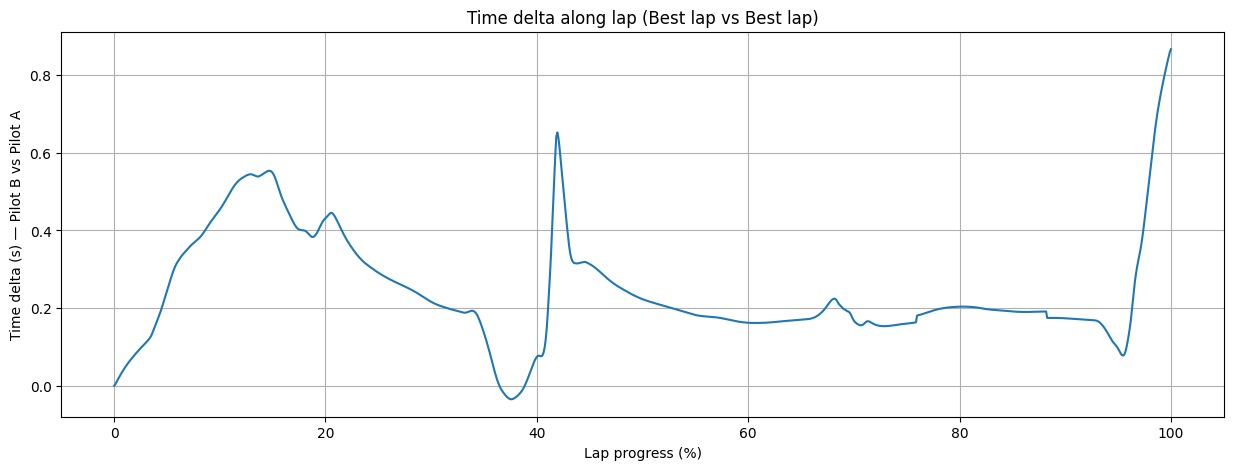

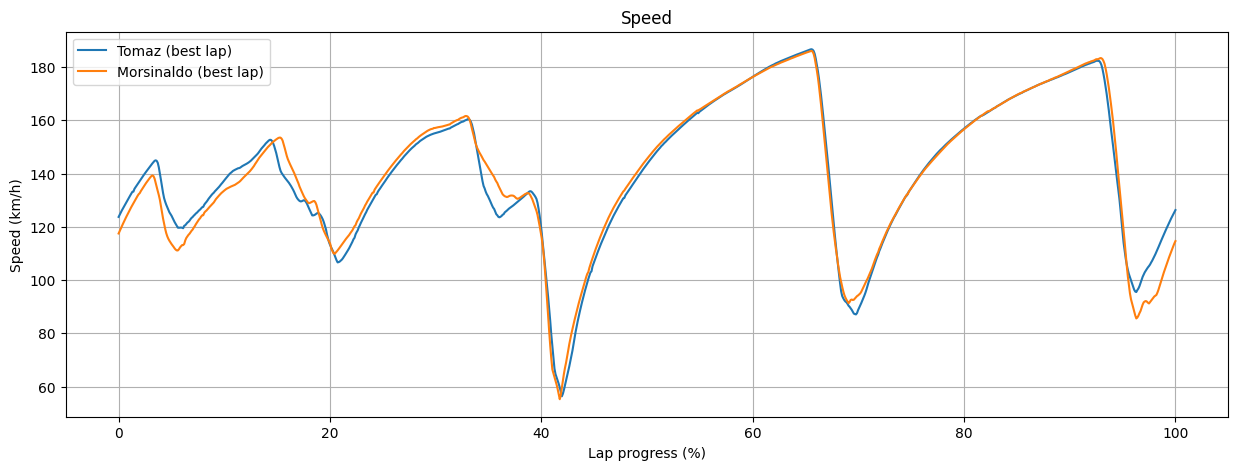

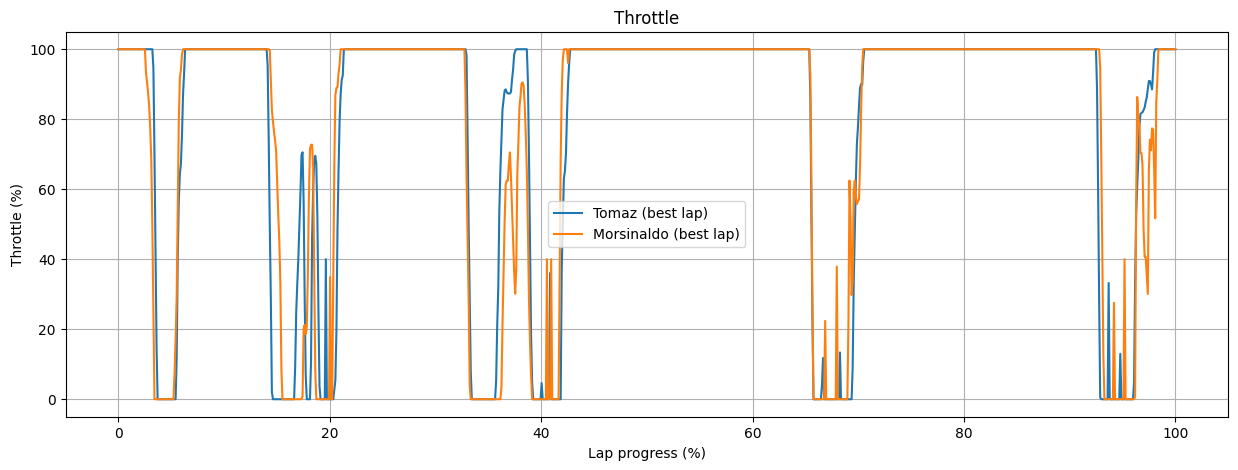

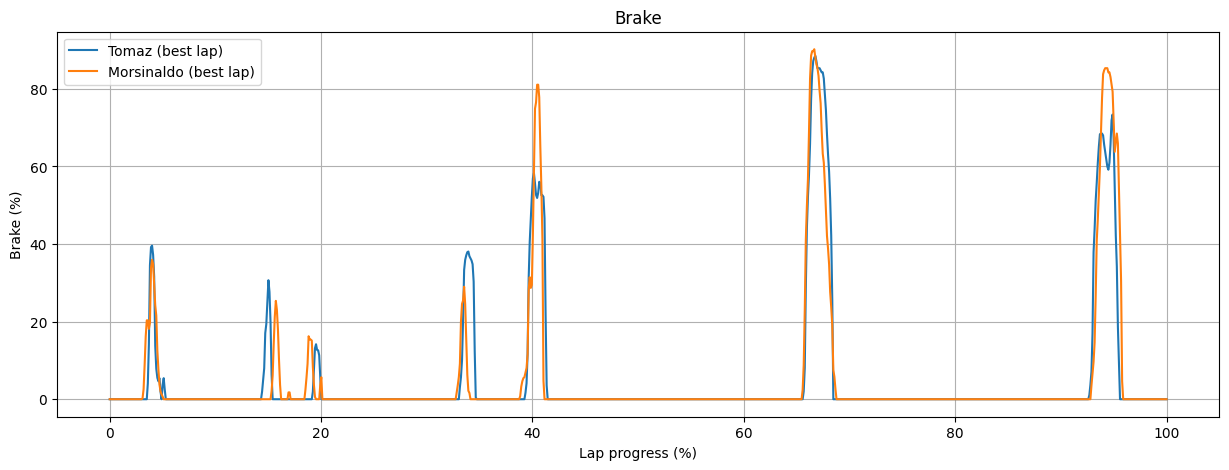

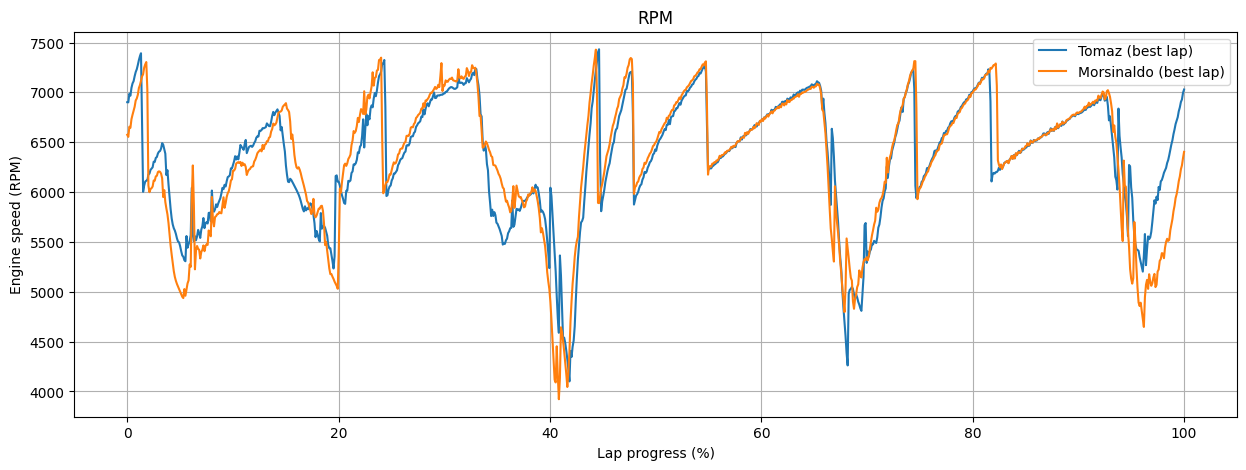

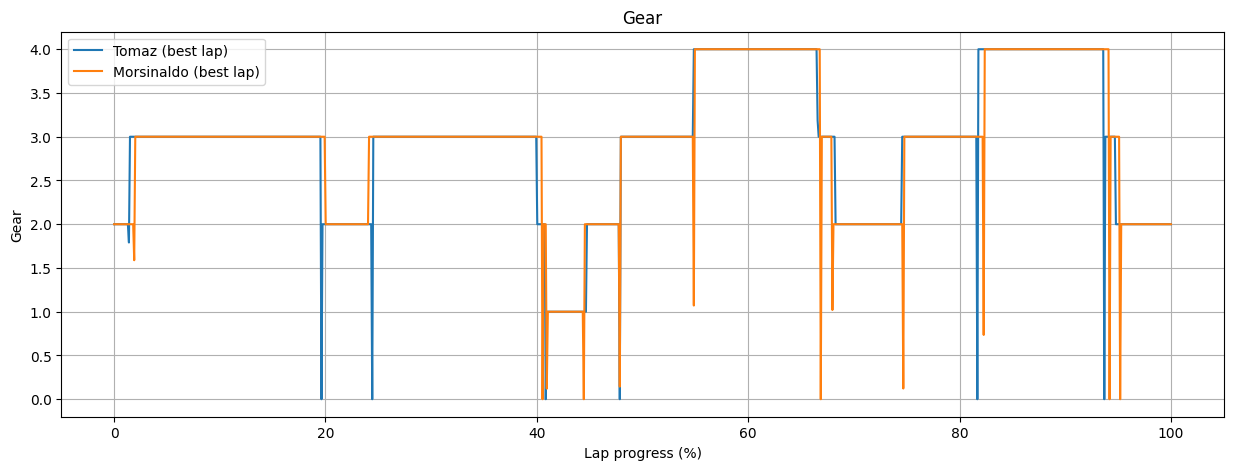

In [ ]:
# --- Piloto A ---
lap_df_A = build_lap_validity_table(tomaz_df)
best_row_A = lap_df_A[lap_df_A["Valid"]].sort_values("LapTime_s").iloc[0]
best_lap_A = int(best_row_A["Lap"])

# --- Piloto B ---
lap_df_B = build_lap_validity_table(morsinaldo_df)
best_row_B = lap_df_B[lap_df_B["Valid"]].sort_values("LapTime_s").iloc[0]
best_lap_B = int(best_row_B["Lap"])

print(f"Piloto A - Best lap: {best_lap_A} ({format_laptime(best_row_A['LapTime_s'])})")
print(f"Piloto B - Best lap: {best_lap_B} ({format_laptime(best_row_B['LapTime_s'])})")

# Alinhamento por distância
grid = np.linspace(0.0, 1.0, BASE_GRID_LEN)

g_A = tomaz_df[tomaz_df["Lap"] == best_lap_A]
g_B = morsinaldo_df[morsinaldo_df["Lap"] == best_lap_B]

interp_A = align_lap_by_dist(g_A, grid)
interp_B = align_lap_by_dist(g_B, grid)


# Time-loss curve (target vs reference)
time_loss = interp_B["t_rel"] - interp_A["t_rel"]

plt.figure(figsize=(15, 5))
plt.plot(grid * 100.0, time_loss)
plt.xlabel("Lap progress (%)")
plt.ylabel("Time delta (s) — Pilot B vs Pilot A")
plt.title("Time delta along lap (Best lap vs Best lap)")
plt.grid(True)
plt.show()

def quick_plot(yA, yB, label, ylab):
    plt.figure(figsize=(15, 5))
    plt.plot(grid * 100.0, yA, label="Tomaz (best lap)")
    plt.plot(grid * 100.0, yB, label="Morsinaldo (best lap)")
    plt.xlabel("Lap progress (%)")
    plt.ylabel(ylab)
    plt.title(label)
    plt.legend()
    plt.grid(True)
    plt.show()

quick_plot(interp_A["speed"],    interp_B["speed"],    "Speed",    "Speed (km/h)")
quick_plot(interp_A["throttle"], interp_B["throttle"], "Throttle", "Throttle (%)")
quick_plot(interp_A["brake"],    interp_B["brake"],    "Brake",    "Brake (%)")
quick_plot(interp_A["RPM"],interp_B["RPM"],"RPM","Engine speed (RPM)")
quick_plot(interp_A["Gear"],interp_B["Gear"],"Gear","Gear")

